# Исследовательсикй анализ лояльности пользователей Яндекс Афиши
- Автор: Серов Константин
- Дата: 09.07.2026

## Цель и задачи  

**Цель:** проведите исследовательский анализ данных, чтобы выяснить, какие пользователи с большей вероятностью возвращаются на платформу и делают заказы повторно. Это позволит:
- Быстро выявлять перспективных клиентов и предлагать им персонализированные условия.
- Точно настраивать рекламу на аудитории с высокой вероятностью возврата.
- Оптимизировать маркетинговые бюджеты.
- Повысить общий уровень удержания клиентов.

**Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Создание профиля пользователя
4. Провести исследовательский анализ данных:
    - Исследование признаков первого заказа и их связи с возвращением на платформу:
      - Изучение распределения пользователей по признакам;
      - Анализ возвратов пользователей;
      - Проверка продуктовых гипотез:
        - **Гипотеза 1**. Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
        - **Гипотеза 2**. В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.
    - Исследование поведения пользователей через показатели выручки и состава заказа:
      - Проследить связь между средней выручкой сервиса с заказа и повторными заказами;
      - Сравнить распределение по средней выручке с заказа в двух группах пользователей (совершившие 2–4 заказа; совершившие 5 и более заказов.);
      - Проанализировать влияние среднего количества билетов в заказе на вероятность повторной покупки;
    - Исследование временных характеристик первого заказа и их влияния на повторные покупки:
      - Проанализировать, как день недели, в который была совершена первая покупка, влияет на поведение пользователей;
      - Изучить, как средний интервал между заказами влияет на удержание клиентов;
    - Корреляционный анализ количества покупок и признаков пользователя:
      - Провести корреляционный анализ;
5. Сформулировать выводы по проведённому анализу.

## Данные
Для анализа поступили данные, хранящиеся в базе данных `data-analyst-afisha` в схеме `afisha`.

Схема `afisha` содержит пять таблиц:
- `purchases` содержит информацию о заказах билетов;
- `events` содержит данные о мероприятиях, доступных на платформе;
- `venues` содержит сведения о площадках проведения мероприятий;
- `city` содержит список городов, относящихся к регионам;
- `regions` содержит список регионов, в которых проводятся мероприятия.

### Описание таблицы `purchases`
Таблица `purchases` содержит семь столбцов:
- `event_id` — идентификатор мероприятия.
- `event_name_code` — название мероприятия в закодированном виде.
- `event_type_description` — описание мероприятия.
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее)
- `organizers` — организаторы мероприятия.
- `city_id` — идентификатор города проведения мероприятия из таблицы `cities`.
- `venue_id` — идентификатор площадки проведения мероприятия из таблицы venues.

### Описание таблицы `events`
Таблица `events` содержит три столбца:
- `venue_id` — идентификатор площадки;
- `venue_name` — название площадки;
- `address` — адрес площадки.

### Описание таблицы `city`
Таблица `city` содержит три столбца:
- `city_id` — идентификатор города;
- `city_name` — название города;
- `region_id` — идентификатор региона, в котором расположен город, из таблицы `regions`.

### Описание таблицы `regions`
Таблица `regions` содержит три столбца:
- `region_id` — идентификатор региона;
- `region_name` — название региона.

### Таблица, сформированная с помощью запроса к БД и хранящая поля, которые позволят изучить поведение пользователей и понять, кто чаще возвращается на платформу и в силу каких факторов.

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (например, mobile — мобильные устройства, desktop — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные created_dt_msk );
- `order_ts` — дата и время создания заказа (используйте данные created_ts_msk );
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней между этой покупкой и предыдущей. Если пользователь совершал только одну покупку, то в столбце должно быть пропущенное значение;
- `event_id` — уникальный идентификатор мероприятия;
- `event_name` — название мероприятия (используйте данные event_name_code);
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

## Структура проекта
1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Итоговые выводы.

---

## Загрузка данных и знакомство с ними

Начнём с загрузки библиотек. Будем использовать `pandas` и библиотеки визуализации данных `matplotlib` и `seaborn`, `phik` для построения матрицы корреляции, а также `sqlalchemy` и `psycopg2` для загрузки данных из БД

In [1]:
# Устанавливаем библиотеки
!pip install sqlalchemy psycopg2-binary phik -U

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Импортируем необходимые библиотеки

In [2]:
# Загружаем библиотеки для подключения к БД и извлечения данных
import pandas as pd
from sqlalchemy import create_engine

# Импортируем библиотеку pandas
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

### Загрузка данных
Устанавливаем параметры подключения к БД

In [3]:
db_config = {'user': 'praktikum_student', # имя пользователя
             'pwd': 'Sdf4$2;d-d30pp', # пароль
             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
             'port': 6432, # порт подключения
             'db': 'data-analyst-afisha' # название базы данных
             }

Формируем строку подключения с помощью метода `format()`

In [4]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

Чтобы создать соединение, строку с данными для подключения передаём функции `create_engine()`:

In [5]:
engine = create_engine(connection_string)

Перед исследовательским анализом был сформирован запрос к БД, формирующий необходимые поля, которые позволят изучить поведение пользователей и понять, кто чаще возвращается на платформу и в силу каких факторов.

Запрос записываем в переменную `query`

In [6]:
query = '''
WITH set_config_precode AS (
  SELECT set_config('synchronize_seqscans', 'off', true)
)
SELECT
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    p.created_dt_msk::date - LAG(p.created_dt_msk::date) OVER (
        PARTITION BY p.user_id 
        ORDER BY p.created_dt_msk::date
    ) AS days_since_prev,
    p.event_id,
    e.event_name_code AS event_name,
    e.event_type_main,
    p.service_name,
    r.region_name,
    c.city_name
FROM purchases p
INNER JOIN events e ON p.event_id = e.event_id
INNER JOIN city c ON e.city_id = c.city_id
INNER JOIN regions r ON c.region_id = r.region_id
WHERE p.device_type_canonical IN ('mobile', 'desktop')
  AND e.event_type_main != 'фильм'
ORDER BY p.user_id
'''

Результат выдачи SQL-запроса можно записать в датафрейм с помощью метода `pd.read_sql_query()`:

In [7]:
from sqlalchemy import create_engine, text

with engine.connect() as connection:
    connection.execute(text("SET search_path TO afisha;"))
    df = pd.read_sql_query(query, con=connection)

---
### Знакомство с данными

Познакомимся с данными сформированного датасета - выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [8]:
# Вывод первых строк датафрейма
df.head(10)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк
5,000898990054619,mobile,2613713,2024-10-23,2024-10-23 15:12:00,rub,902.74,3,19.0,500862,9cc55c15-4375-4129-9979-3129688ba1b4,концерты,Облачко,Лугоградская область,Кристалевск
6,00096d1f542ab2b,desktop,6636941,2024-08-15,2024-08-15 16:48:48,rub,917.83,4,NaN,201953,2f98d69f-4e60-4ffc-8f16-e539383526b1,театр,Край билетов,Каменевский регион,Глиногорск
7,000a55a418c128c,mobile,4657981,2024-09-29,2024-09-29 19:39:12,rub,47.78,1,NaN,265857,0d876e01-851e-458b-ba61-753e0e0c4063,театр,Лучшие билеты,Поленовский край,Дальнозолотск
8,000a55a418c128c,mobile,4657952,2024-10-15,2024-10-15 10:29:04,rub,74.84,2,16.0,271579,ddc795f8-7ef8-4eb0-b299-cb3e6ee24ba1,театр,Лучшие билеты,Поленовский край,Дальнозолотск
9,000cf0659a9f40f,mobile,6818017,2024-06-20,2024-06-20 10:35:26,rub,1421.91,4,NaN,516728,11be386f-7cb7-4aa1-a8e4-ba73a29c1af2,концерты,Лови билет!,Широковская область,Радужнополье


In [9]:
# Общая информация о датафрейме
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


Датасет содержит 15 столбцов и 290611 строк, в которых представлена информация, позволяющая изучить поведение пользователей и понять, кто чаще возвращается на платформу и в силу каких факторов. Замечено наличие пропущенных значений в столбе `days_since_prev` - (290611 − 268678 =) 21933 пропуска.

Среди представленных данных 2 столбца содержат дату/время (`datetime64[us]`), 3 столбца — целочисленные значения (`int64`), 2 столбца — вещественные числа (`float64`), 8 столбцов — строковые значения (`str`).

**Изучим типы данных и их корректность:**
- **Дата и время (`datetime64[us]`)**:
  - `order_dt` и `order_ts` — оба содержат дату создания заказа, но `order_ts` дополнительно хранит время. По сути `order_dt` — это урезанная версия `order_ts` (без времени).
- **Целочисленные значения (`int64`)**:
  - `order_id` и `event_id` — уникальные идентификаторы заказов и мероприятий. Тип корректен, но размерность этих данных можно оптимизировать.
  - `tickets_count` — количество билетов в заказе, целое число, тип корректен. Стоит проверить диапазон значений на выбросы (например, аномально большие заказы). Размерность этих данных можно оптимизировать.
- **Вещественные значения (`float64`)**:
  - `revenue` — выручка от заказа. Тип корректен, но значения выражены в разных валютах (rub и, предположительно, kzt), поэтому сравнивать/суммировать выручку по строкам нужно с учётом `currency_code`.
  - `days_since_prev` — количество дней с предыдущей покупки пользователя. 21933 пропуска. Основной частью этих пропусков скорее всего является ожидаемым поведением оконной функции `LAG()`: для первой покупки пользователя предыдущей записи не существует, поэтому значение NaN. По сути, количество таких пропусков говорит нам о количестве пользователей, сделавших хотя бы один заказ. Заполнять эти пропуски нельзя — они несут смысл. Пропуски иной природы стоит проверить.
- **Строковые данные (`str`)**: `user_id`, `device_type_canonical`, `currency_code`, `event_name`, `event_type_main`, `service_name`, `region_name`, `city_name`:
  - `user_id` — уникальный идентификатор пользователя, тип `str` корректен.
  - `device_type_canonical` — судя по образцу данных, всего два значения ("mobile", "desktop"); при 290к строк это явный кандидат на перевод в `category` для экономии памяти.
  - `currency_code` — валюта оплаты, тп данных `str` корректен. Судя по образцу, пока видно только rub, но валюта хорошо подходит под категориальный тип данных `category` для экономии памяти.
  - `event_name` — закодированное название мероприятия (похоже на хеш-строку), тип `str` корректен.
  - `event_type_main` — тип мероприятия (театр, выставки, концерты, стендап, другое и т.д.), ограниченный набор значений — кандидат на category.
  - `service_name` — название билетного оператора. По описанию известно, что распределение неравномерное (есть лидеры и мелкие операторы), но само число уникальных значений нужно проверить — вероятный кандидат на `category`.
  - `region_name` и `city_name` — название региона, в котором прошло мероприятие и название города, в котором прошло мероприятие. Тип `str` корректен.

Первичное знакомство показывает, что типы данных в датасете в целом соответствуют содержимому и не требуют кардинальных изменений, однако есть возможности для оптимизации памяти. `order_id`, `event_id`, `tickets_count` -> уменьшение размерности; `device_type_canonical`, `currency_code`, `event_type_main` -> тип `category`. Столбец `days_since_prev` содержит пропуски (21933). Основная причина их возникновения, предположительно, -  результат работы оконной функции LAG(). Они работают как флаг первого заказа пользователя, это содержательная информация, поэтому оставляем пропуски как есть. Стоит провести более глубокий аналиж пропусков.

---

Перед преобразованиями сделаем копию текущего датасета

In [10]:
temp = df.copy() 
len(temp)

290611

## Предобработка данных
Подготовим данные к исследовательскому анализу.

### Приведение к единой валюте
Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведём выручку к единой валюте — российскому рублю.

Для этого используем датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. 

In [11]:
# Сохраним датасет в переменную
tenge_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

Познакомимся с данными датасета `final_tickets_tenge_df.csv` - выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [12]:
tenge_df.head(10)

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt
5,2024-01-15,100,19.4501,kzt
6,2024-01-16,100,19.4264,kzt
7,2024-01-17,100,19.4177,kzt
8,2024-01-18,100,19.5798,kzt
9,2024-01-19,100,19.5741,kzt


In [13]:
tenge_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    str    
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    str    
dtypes: float64(1), int64(1), str(2)
memory usage: 11.3 KB


Датасет `final_tickets_tenge_df.csv` содержит 4 столбца и 357 строк, в которых представлена информация о курсе казахстанского тенге по отношению к российскому рублю за 2024 год.

**Изучим типы данных и их корректность**:
Среди представленных данных 2 столбца содержат числовые значения и хранятся в типах данных `int64` или `float64`, и 2 столбца содержат строковые значения и имеют тип данных `str`.
- **Целые числовые значения (int64):**
  - Значения в столбце `nominal` представлены целыми числами и хранят номинал валюты, по отношению к которому представлен курс. Судя по информации этот столбец содержит единственное значение - 100, поэтому размерность этих данных можно оптимизировать.
- **Числовые значения с плавающей точкой (float64):**
  - столбец `curs` содержит информацию о курсе рубля к значению из столбца `nominal`. Тип корректен, но можно оптимизировать.
- **Строковые данные (str):**
  - столбец `data`содержит информацию о дате. Для объединения таблиц по дате тип стоит привести к `datetime`
  - `cdx` — везде kzt, просто маркер валюты. Тип корректен.
Также интересно, что в таблице 357 строк, а не 365, как дней в году. Значит по датам есть пропуски.

Таблица курсов `tenge_df` содержит 357 записей за 2024 год с курсом тенге к рублю (рублей за 100 тенге). Столбец `data` хранится как строка и требует приведения к `datetime` перед объединением с основным датафреймом. Количество записей меньше числа дней в году, что указывает на пропуски в датах (вероятно, выходные/праздничные дни), поэтому прямой мёрдж по точной дате может дать `NaN` для части заказов — потребуется стратегия заполнения.

Перед преобразованиями сделаем копию текущего датасета 

In [14]:
temp_tenge_df = tenge_df.copy() 

In [15]:
# Выводим уникальные значения столбца nominal
tenge_df.nominal.unique()

array([100])

В столбце `nominal` действительно хранятся только сотни.

In [16]:
# Приводим столбец data к типу datetime для последующего merge с order_dt
tenge_df.data = pd.to_datetime(tenge_df.data)

In [17]:
# Посмотрим на преобразование типов данных в датафрейме с помощью атрибута dtypes
comparison = pd.concat([temp_tenge_df.dtypes, tenge_df.dtypes], axis=1, keys=['до', 'после'])
comparison

,до,после
data,str,datetime64[us]
nominal,int64,int64
curs,float64,float64
cdx,str,str


Возьмём даты заказов с `currency_code == 'kzt'` в `df` и сравним с датами в `tenge_df`. Проверим, есть ли даты заказов, для которых нет точного совпадения в курсах. Это покажет, можно ли обойтись обычным мёрджем.

In [18]:
# Уникальные даты заказов с валютой kzt в основном датафрейме
kzt_dates = df.loc[df.currency_code == 'kzt', 'order_dt'].dt.normalize().unique()

In [19]:
# Уникальные даты в таблице курсов
tenge_dates = tenge_df.data.unique()

In [20]:
# Даты заказов в kzt, для которых нет точного совпадения по курсу
missing_dates = set(kzt_dates) - set(tenge_dates)

In [21]:
print(f'Дат заказов в kzt: {len(kzt_dates)}')
print(f'Дат без курса в tenge_df: {len(missing_dates)}')
if missing_dates:
    print(sorted(missing_dates)[:10])  # первые 10 для примера

Дат заказов в kzt: 153
Дат без курса в tenge_df: 0


`missing_dates` пустое — для всех 153 дат заказов в тенге есть точный курс в `tenge_df`. Значит можно обойтись обычным мёрдж по дате.

**Приступаем к конвертации валюты:**

In [22]:
# Присоединяем курс тенге к основному датафрейму по дате заказа
df = df.merge(
    tenge_df[['data', 'curs']],
    left_on = df['order_dt'].dt.normalize(),
    right_on = 'data',
    how = 'left'
)

Результаты преобразования сохраняем в новый столбец `revenue_rub`.

In [23]:
# Считаем выручку в рублях: для rub — без изменений, для kzt — пересчёт по курсу
df['revenue_rub'] = df['revenue'].where(
    df['currency_code'] == 'rub',
    df['revenue'] / tenge_df['nominal'].iloc[0] * df['curs']
)

In [24]:
# Убираем вспомогательные столбцы, оставшиеся после merge
df = df.drop(columns = ['data', 'curs'])

In [25]:
# Не появились ли пропуски в revenue_rub там, где их быть не должно
df['revenue_rub'].isna().sum()

np.int64(0)

Отлично, 0 пропусков — конвертация прошла чисто, ни одна строка не потеряна и не осталась без значения `revenue_rub`.

Выручка приведена к единой валюте — российскому рублю — в новом столбце revenue_rub. Для заказов в рублях значение осталось без изменений, для заказов в тенге выполнен пересчёт по курсу ЦБ на дату заказа (курс тенге, привязанный к дате заказа, был присоединён через мёрдж). После конвертации пропусков в `revenue_rub` не обнаружено — все 290611 строк получили корректное значение выручки в рублях.

---

### Оптимизируем типы данных
На очереди 6 кандидатов: `order_id`, `event_id`, `tickets_count`, `device_type_canonical`, `currency_code` и `event_type_main`.
- **столбцы `order_id`, `event_id`, `tickets_count`** имеют данные типа `int64`, для оптимизации будем использовать метод `pd.to_numeric` с аргументом `downcast='int'`;

In [26]:
# Оптимизируем данные столбцов order_id и event_id
df['order_id'] = pd.to_numeric(df['order_id'], downcast='integer')
df['event_id'] = pd.to_numeric(df['event_id'], downcast='integer')
df['tickets_count'] = pd.to_numeric(df['tickets_count'], downcast='integer')

- **столбец `device_type_canonical`** имеет данные типа `str`. Посмотрим уникальные значения столбца:

In [27]:
df['device_type_canonical'].unique()

<StringArray>
['mobile', 'desktop']
Length: 2, dtype: str

Столбец `device_type_canonical` имеет только два уникальных значения, стоит привести данные столбца к типу `category`:

In [28]:
# Выполняем преобразование типа для столбца device_type_canonical
df['device_type_canonical'] = df['device_type_canonical'].astype('category')

- **столбец `currency_code`** имеет данные типа `str`. Посмотрим уникальные значения столбца:

In [29]:
df['currency_code'].unique()

<StringArray>
['rub', 'kzt']
Length: 2, dtype: str

Столбец `currency_code` имеет только два уникальных значения, стоит привести данные столбца к типу `category`:

In [30]:
# Выполняем преобразование типа для столбца currency_code
df['currency_code'] = df['currency_code'].astype('category')

- **столбец `event_type_main`** имеет данные типа `str`. Посмотрим уникальные значения столбца:

In [31]:
df['event_type_main'].unique()

<StringArray>
['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт', 'ёлки']
Length: 7, dtype: str

Столбец `event_type_main` имеет 7 уникальных значения, стоит привести данные столбца к типу `category`:

In [32]:
# Выполняем преобразование типа для столбца event_type_main
df['event_type_main'] = df['event_type_main'].astype('category')

In [33]:
# Посмотрим на преобразование типов данных в датафрейме с помощью атрибута dtypes
comparison = pd.concat([temp.dtypes, df.dtypes], axis=1, keys=['до', 'после'])
comparison

,до,после
user_id,str,str
device_type_canonical,str,category
order_id,int64,int32
order_dt,datetime64[us],datetime64[us]
order_ts,datetime64[us],datetime64[us]
currency_code,str,category
revenue,float64,float64
tickets_count,int64,int8
days_since_prev,float64,float64
event_id,int64,int32


Типы данных шести столбцов были успешно оптимизированы: `order_id` приведён к `int32`, `tickets_count` - к `int8`, `event_id` - к `int32`. Столбцы `device_type_canonical`, `currency_code` и `event_type_name` переведены в тип `category` для экономии памяти. У столбца `revenue_rub` изначально тип `Nan`, потому что его не было в исходной таблице `df`. 

### Проверяем наличие пропусков в данных

Проверим данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.

In [34]:
# Проверяем количество пропусков по каждому столбцу датафрейма
comparison = pd.concat([df.isna().sum(), (df.isna().sum() / len(df) * 100).round(2)], axis=1, keys=['Абсолютное значение', 'Процентное соотношение'])
comparison

,Абсолютное значение,Процентное соотношение
user_id,0,0.00
device_type_canonical,0,0.00
order_id,0,0.00
order_dt,0,0.00
order_ts,0,0.00
currency_code,0,0.00
revenue,0,0.00
tickets_count,0,0.00
days_since_prev,21933,7.55
event_id,0,0.00


В столбце `days_since_prev` 7.55% пропусков (21933).

Предположительно, основная часть этих пропусков является результатом работы функции `LAG()` и обозначают пользователей, сделавших хотя бы один заказ. Проверим, если пропуски в `days_since_prev` объясняются только работой `LAG()`, то их количество должно точно совпадать с количеством уникальных пользователей, ведь у каждого пользователя ровно одна первая покупка получает `NaN`.

In [35]:
n_missing = df['days_since_prev'].isna().sum()
n_unique_users = df['user_id'].nunique()

print(f'Пропусков в days_since_prev: {n_missing}')
print(f'Уникальных пользователей: {n_unique_users}')
print(f'Совпадает: {n_missing == n_unique_users}')

Пропусков в days_since_prev: 21933
Уникальных пользователей: 21933
Совпадает: True


Предположение подтвердилось - все пропуски в столбце `days_since_prev` являются результатом работы функции `LAG()` и показывают первый заказ пользователя.

---

### Проверка распределения численных данных и наличие в них выбросов
Для этого используем статистические показатели, гистограммы распределения значений или диаграммы размаха. Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверим данные в этих столбцах. Если обнаружим выбросы в поле `revenue_rub`, то отфильтруем значения по 99 перцентилю.

**Статистические показатели**

In [36]:
# Статистика по выручке и количеству билетов в заказе
df[['revenue_rub', 'tickets_count']].describe()

,revenue_rub,tickets_count
count,290611.000000,290611.000000
mean,555.571987,2.754311
std,875.498172,1.170620
min,-90.760000,1.000000
25%,113.970000,2.000000
50%,351.140000,3.000000
75%,802.050000,4.000000
max,81174.540000,57.000000


**`revenue_rub`**: `mean` (555.57) заметно больше `median` (351.14), а `max` (81174.54) в ~101 раз больше 75% квартиля (802.05). Характерно для сильно скошенного вправо распределения с выбросами — фильтрация по 99-му перцентилю здесь оправдана.

`min` у `revenue_rub` — это -90.76 — отрицательная выручка. Отрицательная выручка с заказа нелогична для продажи билета. Это может быть возврат/отмена заказа или ошибка в данных или в конвертации валюты. Нужно понять природу этого явления, прежде чем вносить какие-либо изменения.

Посмотрим, сколько всего строк с отрицательной выручкой.

In [37]:
# Сколько строк с отрицательной выручкой и как они распределены
neg_revenue = df[df['revenue_rub'] < 0]
print(f'Количество строк с отрицательной выручкой: {len(neg_revenue)}')
print(f'Доля от всех данных: {len(neg_revenue) / len(df) * 100:.3f}%')

Количество строк с отрицательной выручкой: 381
Доля от всех данных: 0.131%


Ещё раз выведем статистику по выручке и количеству билетов в заказе, но уже только по отрицательным значениям.

In [38]:
neg_revenue[['tickets_count', 'revenue_rub']].describe()

,tickets_count,revenue_rub
count,381.000000,381.000000
mean,2.115486,-2.492362
std,0.969154,5.065072
min,1.000000,-90.760000
25%,1.000000,-3.450000
50%,2.000000,-1.580000
75%,3.000000,-0.650000
max,6.000000,-0.010000


Отрицательные значения `revenue_rub` (381 строка, 0.132% данных) — это небольшие по модулю значения (от -0.01 до -90.76 руб), с нормальным значением `tickets_count`. Такие значения скорее указывают на частичную корректировку или возвраты, чем на грубую ошибку данных или системную проблему конвертации. Поскольку отрицательная сумма физически не может отражать продажу билета, а анализ строится именно на выручке с продаж, эти строки стоит исключить из датасета отдельным шагом, до фильтрации по 99-му перцентилю.

**`tickets_count`**: тоже скошено, но не так сильно — `max` (57) в ~14 раз больше 75% (4). Заказ на 57 билетов физически возможен (корпоративная закупка, групповая бронь), хотя для отдельного пользователя это редкость.

Воспользуемся **диаграммой размаха значений** для визуализации

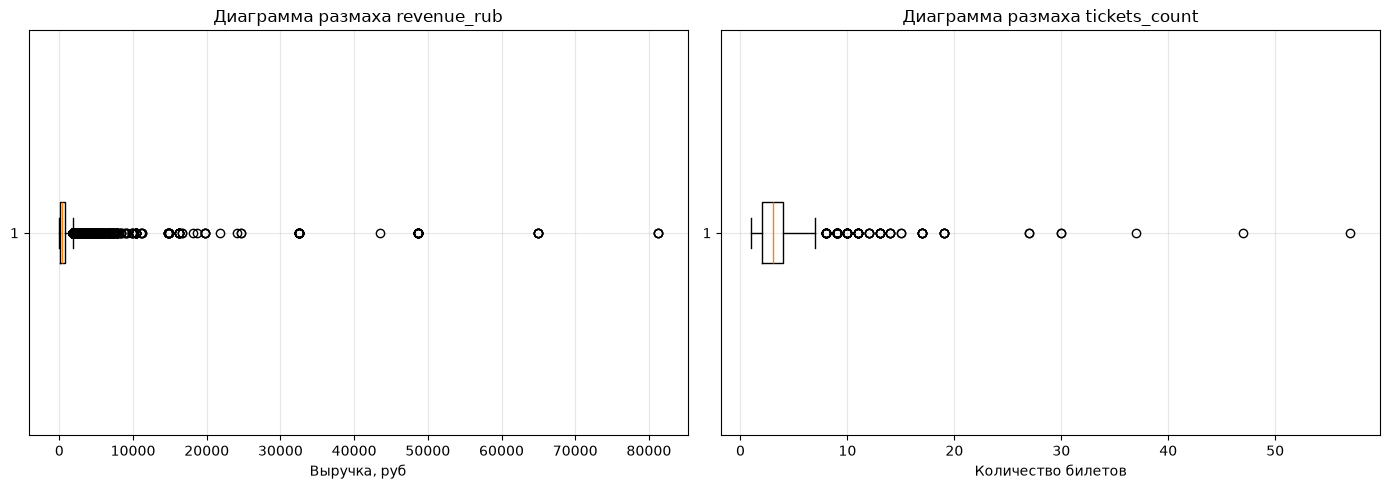

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Диаграмма размаха revenue_rub
axes[0].boxplot(df['revenue_rub'], orientation = 'horizontal')
axes[0].set_title('Диаграмма размаха revenue_rub')
axes[0].set_xlabel('Выручка, руб')
axes[0].grid(True, alpha = 0.3)

# Диаграмма размаха tickets_count
axes[1].boxplot(df['tickets_count'], orientation = 'horizontal')
axes[1].set_title('Диаграмма размаха tickets_count')
axes[1].set_xlabel('Количество билетов')
axes[1].grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

Диаграммы размаха подтверждают картину из `describe()`: у обоих признаков — узкий "ящик" вблизи нуля (медианные значения) и длинный правый хвост из множества точек-выбросов, вплоть до экстремальных значений (~81 тыс. руб для `revenue_rub` и 57 билетов для `tickets_count`). Основная масса заказов сконцентрирована в небольшом диапазоне, а выбросы не единичны — это плотный шлейф точек, что подтверждает обоснованность фильтрации revenue_rub по 99-му перцентилю.

**Фильтрация отрицательных значений и по 99-му перцентилю**

In [40]:
rows_before = len(df)

# Убираем строки с отрицательной выручкой — технический артефакт, 
# не может отражать продажу билета (см. вывод выше)
df = df[df['revenue_rub'] >= 0]
rows_after_negative = len(df)

# Фильтруем оставшиеся данные по 99 перцентилю revenue_rub
p99 = df['revenue_rub'].quantile(0.99)
df = df[df['revenue_rub'] <= p99]
rows_after_p99 = len(df)

print(f'99-й перцентиль revenue_rub: {p99:.2f}')
print(f'Строк до фильтрации: {rows_before}')
print(f'После удаления отрицательной выручки: {rows_after_negative} (убрано {rows_before - rows_after_negative})')
print(f'После фильтрации по 99 перцентилю: {rows_after_p99} (убрано {rows_after_negative - rows_after_p99})')
print(f'Итого отфильтровано: {rows_before - rows_after_p99} ({(rows_before - rows_after_p99) / rows_before * 100:.2f}%)')

99-й перцентиль revenue_rub: 2628.42
Строк до фильтрации: 290611
После удаления отрицательной выручки: 290230 (убрано 381)
После фильтрации по 99 перцентилю: 287405 (убрано 2825)
Итого отфильтровано: 3206 (1.10%)


In [41]:
# Статистика по выручке и количеству билетов в заказе после фильтрации
df[['revenue_rub', 'tickets_count']].describe()

,revenue_rub,tickets_count
count,287405.000000,287405.000000
mean,518.719256,2.741323
std,511.951842,1.163087
min,0.000000,1.000000
25%,112.600000,2.000000
50%,344.830000,3.000000
75%,788.900000,3.000000
max,2628.421739,57.000000


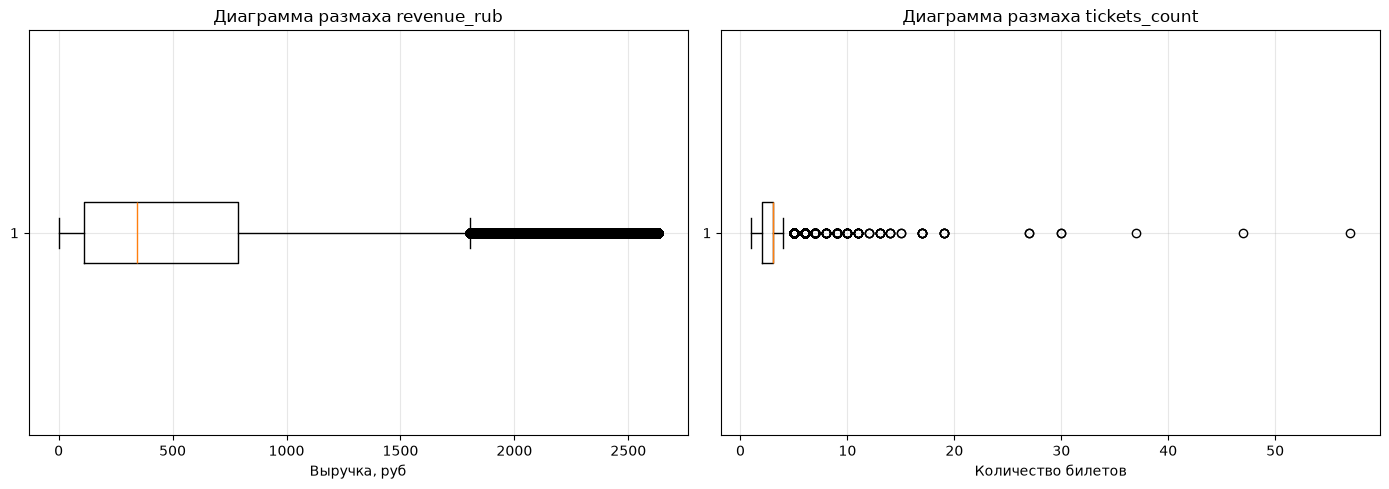

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Диаграмма размаха revenue_rub
axes[0].boxplot(df['revenue_rub'], orientation = 'horizontal')
axes[0].set_title('Диаграмма размаха revenue_rub')
axes[0].set_xlabel('Выручка, руб')
axes[0].grid(True, alpha = 0.3)

# Диаграмма размаха tickets_count
axes[1].boxplot(df['tickets_count'], orientation = 'horizontal')
axes[1].set_title('Диаграмма размаха tickets_count')
axes[1].set_xlabel('Количество билетов')
axes[1].grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

За этап предобработки из исходных 290611 строк отфильтровано 3206 (1.10%): 381 строка с отрицательной выручкой удалена как технический артефакт, ещё 2825 строк отсечены по 99-му перцентилю (p99 = 2628.42 руб). После фильтрации осталось 287405 строк — распределение стало заметно компактнее: `max` снизился с 81174 до 2628 руб, среднее приблизилось к медиане (518.72 против 344.83, было 555.57 против 351.14), что говорит о заметном уменьшении скошенности вправо.

`tickets_count` фильтрации не подвергался, поэтому его статистика не изменилась.

---

### Промежуточные выводы после предобработки
В ходе предобработки выполнены следующие действия:
- **Приведение выручки к единой валюте.** Выручка в тенге пересчитана в рубли по курсу на дату заказа (курс присоединён из справочника `final_tickets_tenge_df.csv`); результат сохранён в новый столбец `revenue_rub`. Пропусков после конвертации не возникло.
- **Оптимизация типов данных.** `order_id`, `event_id`, `tickets_count` приведены к более компактным целочисленным типам (`int32`/`int8`) без потери информации; `device_type_canonical`, `currency_code`, `event_type_main` переведены в `category` — на основании низкого числа уникальных значений относительно объёма данных.
- **Проверка пропусков.** Пропуски обнаружены только в `days_since_prev` (21933 строки, 7.55%) и подтверждены как ожидаемое следствие оконной функции `LAG()` для первой покупки пользователя; пропусков другой природы не найдено.
- **Обработка аномалий и выбросов в `revenue_rub`.** Обнаружено и удалено 381 строка (0.132%) с отрицательной выручкой. Дополнительно данные отфильтрованы по 99-му перцентилю `revenue_rub` (порог 2628.42 руб), убрано ещё 2825 строк.

**Итог:** из исходных 290611 строк отфильтровано 3206 (1.10%), в датасете осталось 287405 строк. Распределение `revenue_rub` стало заметно компактнее (`max` снизился с 81174 до 2628 руб, среднее сблизилось с медианой), что подтверждает эффективность фильтрации без риска потери репрезентативности выборки.

---

## Создание профиля пользователя
В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

Построим профиль пользователя — для каждого пользователя найдём:
- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле event_type_main );
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

Но перед тем как строить профиль, отсортируем данные по времени совершения заказа.

In [43]:
# Создадим копию датасета перед созданием профиля пользователя
df_before_profile = df.copy()

In [44]:
# Сортируем данные по времени заказа 
df = df.sort_values('order_ts')

In [45]:
# Построим профиль пользователя
user_profile = df.groupby('user_id').agg(
    first_order_date = ('order_dt', 'min'),
    last_order_date = ('order_dt', 'max'),
    first_device = ('device_type_canonical', 'first'),
    first_region = ('region_name', 'first'),
    first_service = ('service_name', 'first'),
    first_genre = ('event_type_main', 'first'),
    total_orders = ('order_id', 'count'),
    avg_revenue_rub = ('revenue_rub', 'mean'),
    avg_tickets_count = ('tickets_count', 'mean'),
    avg_days_between = ('days_since_prev', 'mean')
).reset_index()

user_profile.head()

,user_id,first_order_date,last_order_date,first_device,first_region,first_service,first_genre,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_between
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaN
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.0
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,NaN
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16.0


In [46]:
# Проверяем целостность построенного профиля
print(f'Строк в user_profile: {len(user_profile)}')
print(f'Уникальных user_id в df: {df["user_id"].nunique()}')
print(f'Совпадает: {len(user_profile) == df["user_id"].nunique()}')
print()
print(f'Сумма total_orders: {user_profile["total_orders"].sum()}')
print(f'Строк в df: {len(df)}')
print(f'Совпадает: {user_profile["total_orders"].sum() == len(df)}')

Строк в user_profile: 21838
Уникальных user_id в df: 21838
Совпадает: True

Сумма total_orders: 287405
Строк в df: 287405
Совпадает: True


- Добавим два бинарных признака:
  - `is_two` — совершил ли пользователь 2 и более заказа;
  - `is_five` — совершил ли пользователь 5 и более заказов.

In [47]:
# Добавляем бинарные признаки: совершил ли пользователь 2+ и 5+ заказов
user_profile['is_two'] = user_profile['total_orders'] >= 2
user_profile['is_five'] = user_profile['total_orders'] >= 5

user_profile[['total_orders', 'is_two', 'is_five']].head(10)

,total_orders,is_two,is_five
0,1,False,False
1,2,True,False
2,3,True,False
3,1,False,False
4,2,True,False
5,13,True,True
6,2,True,False
7,1,False,False
8,1,False,False
9,3,True,False


### Анализ репрезентативности данных
Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными мы работаем: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитаем:
- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

In [48]:
# Общее число пользователей в выборке
n_users = len(user_profile)

# Средняя выручка с одного заказа
avg_revenue_per_order = (
    (user_profile['avg_revenue_rub'] * user_profile['total_orders']).sum() 
    / user_profile['total_orders'].sum()
)

# Доля пользователей, совершивших 2 и более заказа
share_two_plus = user_profile['is_two'].mean()

# Доля пользователей, совершивших 5 и более заказов
share_five_plus = user_profile['is_five'].mean()

# Информативный вывод
print(f'Общее число пользователей: {n_users}')
print(f'Средняя выручка с одного заказа: {avg_revenue_per_order:.2f} руб')
print(f'Доля пользователей с 2+ заказами: {share_two_plus:.2%}')
print(f'Доля пользователей с 5+ заказами: {share_five_plus:.2%}')

Общее число пользователей: 21838
Средняя выручка с одного заказа: 518.72 руб
Доля пользователей с 2+ заказами: 61.70%
Доля пользователей с 5+ заказами: 29.00%


Также изучим статистические показатели:
- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

In [49]:
# Статистические показатели по ключевым полям профиля пользователя
user_profile[['total_orders', 'avg_tickets_count', 'avg_days_between']].describe()

,total_orders,avg_tickets_count,avg_days_between
count,21838.000000,21838.000000,13511.000000
mean,13.160775,2.744062,15.847068
std,121.577370,0.913083,22.304516
min,1.000000,1.000000,0.000000
25%,1.000000,2.000000,1.000000
50%,2.000000,2.750000,8.000000
75%,5.000000,3.080000,20.414286
max,10168.000000,11.000000,148.000000


- **Объём:** 21838 пользователей — вполне достаточно по объёму для дальнейшего EDA и корреляционного анализа, выборка репрезентативна по размеру.
- **`total_orders`** — есть явная аномалия. `mean` (13.16) в 6.5 раз больше медианы (2) — сигнал о наличии хвоста. Бросается в глаза `max = 10168` при `75% = 5`: это заказы в ~2000 раз больше типичного пользователя третьего квартиля. Физически 10168 заказов за период сбора данных (около года) означает больше 27 заказов в день. Это либо технический/тестовый аккаунт, либо агрегатор (например, корпоративный закупщик, покупающий пачками через один и тот же user_id), либо ошибка данных (задвоение id). Это выброс, который нужно обрабатывать отдельно.
- **`avg_tickets_count`** - `max = 11` при `75% = 3.08` — это выше среднего, но несильно, и физически заказ на 11 билетов вполне правдоподобен. `std = 0.91` — распределение довольно плотное. Фильтровать нет необходимости.
- **`avg_days_between`**: `count = 13511`, меньше чем 21838 — ожидаемо, это пользователи с 2+ заказами (у кого 1 заказ, там NaN). `max = 148` дней — на годовом окне данных это нормально, не аномалия.

Прежде чем резать по конкретному перцентилю, посмотрим, насколько плотный хвост у больших значений:

In [50]:
# Смотрим перцентили total_orders, чтобы понять масштаб хвоста
for p in [90, 95, 99, 99.9]:
    print(f'{p} перцентиль total_orders: {user_profile["total_orders"].quantile(p / 100):.1f}')

print(f'Максимум: {user_profile["total_orders"].max()}')

# Сколько пользователей вообще имеют экстремально много заказов
print(f'Пользователей с total_orders > 100: {(user_profile["total_orders"] > 100).sum()}')
print(f'Пользователей с total_orders > 50: {(user_profile["total_orders"] > 50).sum()}')

90 перцентиль total_orders: 15.0
95 перцентиль total_orders: 31.0
99 перцентиль total_orders: 152.0
99.9 перцентиль total_orders: 1462.1
Максимум: 10168
Пользователей с total_orders > 100: 352
Пользователей с total_orders > 50: 702


Перцентили показывают, что аномалия не единичная, а системная. Разрыв между перцентилями нарастает нелинейно и очень резко:
- между 90-м и 95-м — рост с 15 до 31 (в 2 раза);
- между 95-м и 99-м — с 31 до 152 (в 5 раз);
- между 99-м и 99.9-м — со 152 до 1462 (почти в 10 раз);
- а максимум (10168) ещё почти в 7 раз больше 99.9-го перцентиля.

Явные признаки юольшого хвоста, а не пары случайных выбросов.

Также, воспользуемся гистограммой и диаграммой размаха значений для визуализации

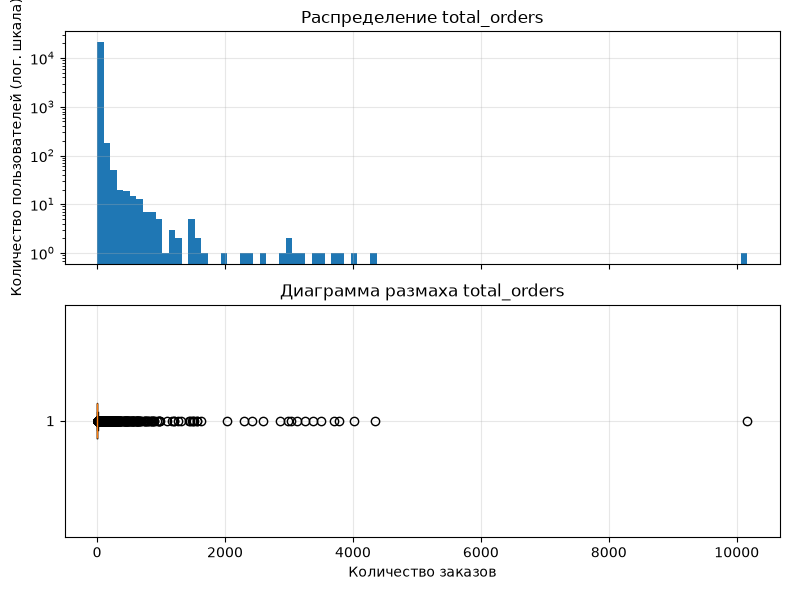

In [51]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex = True)

# Гистограмма total_orders (логарифмическая шкала по Y — 
# иначе редкие, но огромные значения сделают основную массу данных невидимой)
axes[0].hist(user_profile['total_orders'], bins = 100)
axes[0].set_title('Распределение total_orders')
axes[0].set_ylabel('Количество пользователей (лог. шкала)')
axes[0].set_yscale('log')
axes[0].grid(True, alpha = 0.3)

# Диаграмма размаха total_orders — та же ось X, что и у гистограммы сверху
axes[1].boxplot(user_profile['total_orders'], orientation = 'horizontal')
axes[1].set_title('Диаграмма размаха total_orders')
axes[1].set_xlabel('Количество заказов')
axes[1].grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

Визуализация подтверждает экстремальную скошенность распределения. Даже на логарифмической шкале по Y видно, что подавляющее большинство пользователей (десятки тысяч) сосредоточены у левого края. Дальше идёт длинный редкий хвост из отдельных точек, растянутый вплоть до 10168. На диаграмме размаха "ящик" (IQR) практически не виден на этом масштабе, он весь сжат у нуля, а вся видимая часть графика — это шлейф выбросов.

Такие объёмы (сотни и тысячи заказов на одного `user_id` за год) физически нехарактерны для частного покупателя билетов — это с высокой вероятностью агрегированная активность (юрлица/корпоративные закупщики, перекупщики, боты или технический артефакт данных, например, общий `user_id`). Для задачи анализа лояльности частных пользователей эти записи искажают картину: они утягивают `mean` и создают ложное впечатление о "супер-лояльных" клиентах, которые на деле не являются целевой аудиторией персонализированных предложений.

**Вывод:** Фильтрация обоснована и уместна — систематический характер хвоста говорит в пользу среза по перцентилю, а не точечного исключения. Осталось выбрать порог — 95-й или 99-й — с учётом того, сколько данных при этом уйдёт и насколько это повлияет на репрезентативность выборки для дальнейшего EDA.

Посмотрим, сколько данных мы потеряем при каждом пороге:

In [52]:
p95 = user_profile['total_orders'].quantile(0.95)
p99 = user_profile['total_orders'].quantile(0.99)

for p, label in [(p95, '95-й'), (p99, '99-й')]:
    n_filtered = (user_profile['total_orders'] > p).sum()
    print(f'{label} перцентиль = {p:.0f} заказов')
    print(f'  Отфильтровано пользователей: {n_filtered} ({n_filtered / len(user_profile):.2%})')
    print(f'  Отфильтровано заказов (из df): {user_profile.loc[user_profile["total_orders"] > p, "total_orders"].sum()}')
    print()

95-й перцентиль = 31 заказов
  Отфильтровано пользователей: 1091 (5.00%)
  Отфильтровано заказов (из df): 203397

99-й перцентиль = 152 заказов
  Отфильтровано пользователей: 216 (0.99%)
  Отфильтровано заказов (из df): 146935



- 99-й перцентиль отсекает всего 0.99% пользователей, но эти 216 человек держат на себе 146935 заказов. Если сумма `total_orders` по всем пользователям равна общему числу заказов в `df` (287405) — это значит, что ~51% всех заказов в датасете сделаны этими 216 аккаунтами.
- При 95-м перцентиле картина ещё серьёзнее: 5% пользователей держат ~71% всех заказов (203397 из 287405).

Это означает, что удалив меньше процента пользователей, мы выбросим из анализа больше половины всей транзакционной активности сервиса.

Такой масшаб (одиночные аккаунты с тысячами заказов за год) указывает не на естественных активных клиентов, а именно на агрегированную/техническую активность, как мы и предполагали раньше.

Прежде чем выбирать порог, нужно понять — эти 216 пользователей действительно все "мусор", или там смешаны и настоящие активные пользователи с несколькими явными аномалиями? Посмотрим на характеристики этой группы:

In [53]:
# Смотрим на характеристики пользователей с очень большим числом заказов
top_users = user_profile[user_profile['total_orders'] > 100]

print(f'Количество: {len(top_users)}')
print()
print('Статистика по этой группе:')
print(top_users[['total_orders', 'avg_tickets_count', 'avg_days_between']].describe())

Количество: 352

Статистика по этой группе:
       total_orders  avg_tickets_count  avg_days_between
count    352.000000         352.000000        352.000000
mean     465.036932           2.715637          0.743705
std      839.189625           0.176818          0.439891
min      101.000000           2.012658          0.014950
25%      129.750000           2.632732          0.327742
50%      194.000000           2.720048          0.726065
75%      444.000000           2.806877          1.126190
max    10168.000000           3.947761          1.480000


- `avg_days_between`: медиана — 0.73 дня, а `max` по всей группе — всего 1.48 дня. Это значит, что даже "наименее активный" из этих 352 пользователей в среднем оформляет заказ чаще, чем раз в полтора дня, без единого исключения во всей группе. Для живого человека покупать билеты на мероприятия ежедневно или через день, стабильно весь год, физически неправдоподобно.
- `avg_tickets_count`: 2.5 - 3 билета в среднем, `std` небольшой (0.18) — стабильный, узкий паттерн без вариативности, типичной для человеческого поведения.
- `min` по `total_orders` в этой группе — 101 заказ, при том что `avg_days_between` там уже 0.01 - 0.3 дня — то есть даже "минимально аномальные" в этой выборке уже полностью укладываются в паттерн, а не являются пограничными случаями.

Ни один пользователь в этой группе не выглядит как обычный активный клиент, который просто чуть более лоялен.

Порог `total_orders > 100` — это не случайно выбранное число и не формальный процентиль, а граница, за которой поведение уже нельзя объяснить обычной активностью человека: пользователи в этой группе делают заказ в среднем чаще, чем раз в полтора дня, без исключений. Такая частота физически нехарактерна для частного покупателя билетов и больше похожа на автоматизированную или агрегированную активность. В отличие от 95-го или 99-го перцентиля, которые режут заранее заданный процент пользователей вне зависимости от смысла, этот порог опирается на реальный паттерн поведения — а значит лучше соответствует задаче анализа лояльности.

Поэтому фильтровать будем не по перцентилю, а по прямому порогу `total_orders > 100` — исключим эти 352 пользователя (1.6% выборки) как нерепрезентативные для анализа лояльности частных клиентов

**Фильтрация данных**:

In [54]:
rows_before = len(user_profile)

# Исключаем пользователей с total_orders > 100 — паттерн частоты заказов
# физически не соответствует поведению частного клиента
user_profile = user_profile[user_profile['total_orders'] <= 100]

rows_after = len(user_profile)
print(f'Пользователей до фильтрации: {rows_before}')
print(f'Пользователей после фильтрации: {rows_after}')
print(f'Отфильтровано: {rows_before - rows_after} ({(rows_before - rows_after) / rows_before * 100:.2f}%)')

Пользователей до фильтрации: 21838
Пользователей после фильтрации: 21486
Отфильтровано: 352 (1.61%)


Это фильтрация на уровне `user_profile`, а не `df` — мы убираем целиком пользователей-аномалий из профиля для дальнейшего EDA, но не трогаем исходный `df` с заказами (если понадобится, например, для других агрегатов).

---

### Выводы по разделу
- **построение профиля**.
  - На основе `df`, отсортированного по `order_t`s, через `groupby('user_id').agg(...)` построен `user_profile` — один пользователь, одна строка.
  - Профиль включает 9 агрегированных признаков: даты первого/последнего заказа, устройство/регион/партнёра/жанр первого заказа, общее число заказов, среднюю выручку в рублях, среднее количество билетов и средний интервал между заказами.
  - Добавлены бинарные признаки `is_two` и `is_five`. Целостность профиля подтверждена двумя проверками: число строк совпало с `df['user_id'].nunique()`, сумма `total_orders` — с общим числом заказов в `df`.
- **репрезентативность и аномалии**.
  - Выборка после агрегации — 21838 пользователей (расхождение с 21933 уникальными `user_id`, которое было в данных до фильтрации `revenue_rub` на этапе предобработки, объясняется полной потерей заказов части пользователей при отсечении выбросов выручки.
  - Средняя выручка с заказа, посчитанная через `user_profile`, совпала с прямым расчётом по `df` (518.72 руб) — подтверждает корректность агрегации.
  - 61.70% пользователей сделали 2+ заказа, 29.00% — 5+.
  - В `total_orders` обнаружена выраженная аномалия: 352 пользователя (1.6%) с частотой заказов, физически невозможной для частного клиента (медианный интервал между заказами — 0.73 дня, максимум по всей аномальной группе — 1.48 дня). В `avg_tickets_count` аномалий не найдено.
  - Решение по фильтрации принято обоснованно: не по формальному перцентилю (95-й/99-й резали бы 51–71% всех заказов при отсечении процента пользователей), а по прямому порогу `total_orders > 100`, опирающемуся на физически неправдоподобный паттерн поведения. Отфильтровано 352 пользователя (1.61%), в `user_profile` осталось 21486.

---

## Исследовательский анализ данных
Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используем профили пользователей.

### Исследование признаков первого заказа и их связи с возвращением на платформу
Исследуем признаки, описывающие первый заказ пользователя, и выясним, влияют ли они на вероятность возвращения пользователя.

**Изучим распределение пользователей по признакам.**
В профиле пользователя `user_profile` есть четыре признака первого заказа:
- `first_genre` — жанр мероприятия
- `first_device` — устройство
- `first_region` — регион
- `first_service` — билетный оператор

Для каждого из этих 4 признаков посчитаем сколько пользователей в каждой категории и какую долю от общего числа пользователей они составляют.

In [55]:
def segment_distribution(df, column):
    """
    Возвращает распределение пользователей по категориям заданной колонки:
    количество и доля от общего числа пользователей.
    """
    counts = df[column].value_counts()
    shares = df[column].value_counts(normalize = True)
    percents = round(shares * 100, 2)
    
    result = pd.DataFrame({
        'Кол-во пользователей': counts,
        'Доля': shares,
        'Процент': percents
    })
    return result

- Распределение по жанру первого мероприятия

In [56]:
# Распределение по жанру первого мероприятия
genre_dist = segment_distribution(user_profile, 'first_genre')
display(genre_dist)

,Кол-во пользователей,Доля,Процент
first_genre,,,
концерты,9495,0.441916,44.19
другое,5375,0.250163,25.02
театр,4221,0.196454,19.65
стендап,1101,0.051243,5.12
спорт,788,0.036675,3.67
выставки,411,0.019129,1.91
ёлки,95,0.004421,0.44


Есть выраженная «точка входа», почти половина пользователей впервые приходят через концерты. Три категории (концерты, другое, театр) вместе дают ~89% всей выборки. Остальные четыре жанра — это хвост.

- Распределение по устройству первой покупки

In [57]:
# Распределение по устройству первой покупки
device_dist = segment_distribution(user_profile, 'first_device')
display(device_dist)

,Кол-во пользователей,Доля,Процент
first_device,,,
mobile,17797,0.828307,82.83
desktop,3689,0.171693,17.17


Подавляющее большинство пользователей заходит с мобильных устройств (~83%). Категорий всего две, длинного хвоста нет, обе группы достаточно крупные (17797 и 3689)

- Распределение по региону первого заказа

In [58]:
# Распределение по региону первого заказа (топ-10, т.к. регионов может быть много)
region_dist = segment_distribution(user_profile, 'first_region')
display(region_dist.head(10))

,Кол-во пользователей,Доля,Процент
first_region,,,
Каменевский регион,7040,0.327655,32.77
Североярская область,3748,0.174439,17.44
Широковская область,1216,0.056595,5.66
Озернинский край,674,0.031369,3.14
Малиновоярский округ,524,0.024388,2.44
Шанырский регион,495,0.023038,2.30
Травяная область,484,0.022526,2.25
Светополянский округ,451,0.020990,2.10
Речиновская область,437,0.020339,2.03


Два региона (Каменевский + Североярская) дают половину всей аудитории (32.77% + 17.44% = 50.21%). После них идёт резкий обрыв, десятки регионов с долями в пределах 0.5 – 5%.

- Распределение по билетному оператору первого заказа

In [59]:
# Распределение по билетному оператору первого заказа (топ-10)
service_dist = segment_distribution(user_profile, 'first_service')
display(service_dist.head(10))

,Кол-во пользователей,Доля,Процент
first_service,,,
Билеты без проблем,5138,0.239132,23.91
Мой билет,2957,0.137624,13.76
Лови билет!,2797,0.130178,13.02
Билеты в руки,2530,0.117751,11.78
Облачко,2162,0.100624,10.06
Весь в билетах,1279,0.059527,5.95
Лучшие билеты,1176,0.054733,5.47
Прачечная,578,0.026901,2.69
Край билетов,452,0.021037,2.10


Вполне равномерное распределение. Сервис "Билеты без проблем" лидирует с небольшим отрывом. В целом, снижение от категории к категории плавное, а не обрывистое. Рынок операторов выглядит умеренно фрагментированным.

Для наглядности добавим визуализацию в виде гистограмм распределения: 

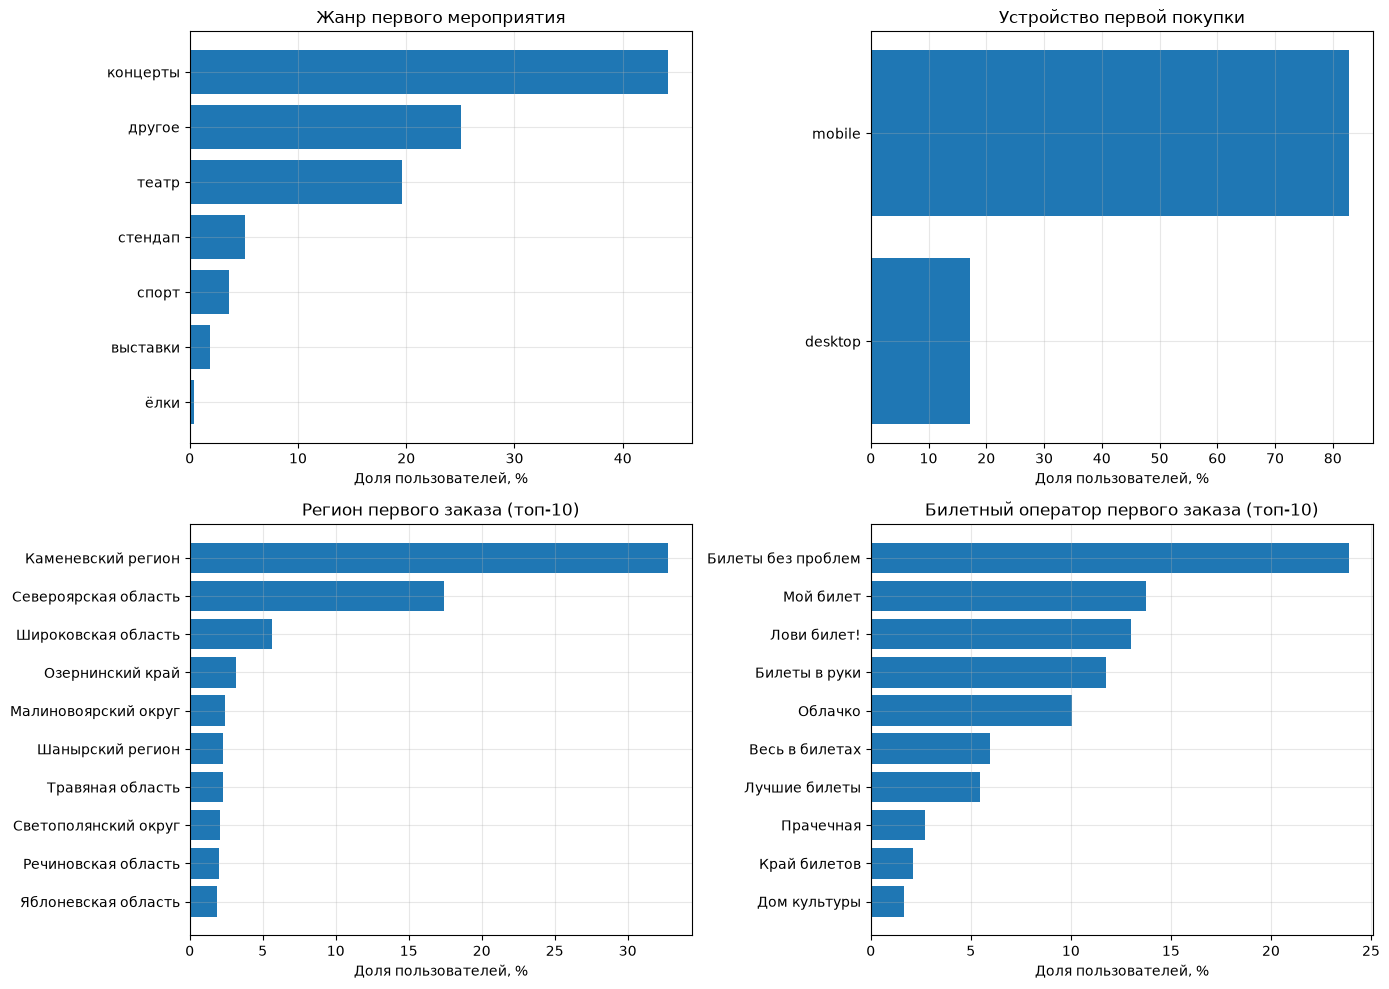

In [60]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Жанр первого мероприятия
axes[0, 0].barh(genre_dist.index[::-1], genre_dist['Процент'][::-1])
axes[0, 0].set_title('Жанр первого мероприятия')
axes[0, 0].set_xlabel('Доля пользователей, %')
axes[0, 0].grid(True, alpha = 0.3)

# Устройство первой покупки
axes[0, 1].barh(device_dist.index[::-1], device_dist['Процент'][::-1])
axes[0, 1].set_title('Устройство первой покупки')
axes[0, 1].set_xlabel('Доля пользователей, %')
axes[0, 1].grid(True, alpha = 0.3)

# Регион первого заказа (топ-10)
region_top10 = region_dist.head(10)
axes[1, 0].barh(region_top10.index[::-1], region_top10['Процент'][::-1])
axes[1, 0].set_title('Регион первого заказа (топ-10)')
axes[1, 0].set_xlabel('Доля пользователей, %')
axes[1, 0].grid(True, alpha = 0.3)

# Билетный оператор первого заказа (топ-10)
service_top10 = service_dist.head(10)
axes[1, 1].barh(service_top10.index[::-1], service_top10['Процент'][::-1])
axes[1, 1].set_title('Билетный оператор первого заказа (топ-10)')
axes[1, 1].set_xlabel('Доля пользователей, %')
axes[1, 1].grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

По всем четырём признакам пользователи распределены неравномерно — везде есть выраженная «точка входа» (концерты / mobile / Каменевский регион / Билеты без проблем), но концентрация разная.

**Проанализируем возвраты пользователей**

Для каждого сегмента вычислим долю пользователей, совершивших два и более заказа.

In [61]:
def segment_return_rate(df, column):
    """
    Возвращает для каждой категории признака:
    количество пользователей, долю от общей выборки,
    и долю пользователей, совершивших 2+ заказа (is_two).
    """
    result = df.groupby(column).agg(
        users_count=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
    result['share_of_total'] = result['users_count'] / len(df)
    
    # Процентные версии для удобства чтения
    result['return_rate_%'] = (result['return_rate'] * 100).round(2)
    result['share_of_total_%'] = (result['share_of_total'] * 100).round(2)
    
    # Сортируем по размеру сегмента, чтобы .head(10) брал крупнейшие сегменты
    result = result.sort_values('users_count', ascending = False)
    return result

In [62]:
# Средняя доля возврата по всей выборке
overall_return_rate = user_profile['is_two'].mean()
print(f'Средняя доля пользователей с 2+ заказами по всей выборке: {overall_return_rate:.2%}')
print()

Средняя доля пользователей с 2+ заказами по всей выборке: 61.08%



- Доля возврата по жанру первого мероприятия

In [63]:
# Доля возврата по жанру первого мероприятия
genre_return = segment_return_rate(user_profile, 'first_genre')
display(genre_return.sort_values('return_rate', ascending=False))

,users_count,return_rate,share_of_total,return_rate_%,share_of_total_%
first_genre,,,,,
выставки,411,0.639903,0.019129,63.99,1.91
театр,4221,0.632315,0.196454,63.23,19.65
концерты,9495,0.615377,0.441916,61.54,44.19
стендап,1101,0.605813,0.051243,60.58,5.12
другое,5375,0.593674,0.250163,59.37,25.02
ёлки,95,0.557895,0.004421,55.79,0.44
спорт,788,0.554569,0.036675,55.46,3.67


Разброс между жанрами небольшой — от 55.5% до 64%. Лидерами по возврату являются `выставки` и `театр`, оба выше среднего. `Театр` имеет приличный объём - 4221 человек, это надёжная оценка. `Выставки` формально на первом месте, но при 411 пользователях доля уже не так стабильна. 

`Концерты` - самый крупный сегмент (9495 чел., 44% всей выборки), даёт возврат почти точно на уровне среднего (61.54% против 61.08%). Это логично — раз он такой большой, он во многом и формирует это среднее.

- Доля возврата по устройству первой покупки

In [64]:
# Доля возврата по устройству первой покупки
device_return = segment_return_rate(user_profile, 'first_device')
display(device_return.sort_values('return_rate', ascending=False))

,users_count,return_rate,share_of_total,return_rate_%,share_of_total_%
first_device,,,,,
desktop,3689,0.635674,0.171693,63.57,17.17
mobile,17797,0.605608,0.828307,60.56,82.83


Два крупных сегмента. Пользователи, впервые пришедшие с десктопа, чуть более склонны возвращаться.

- Доля возврата по региону первого заказа

In [65]:
# Доля возврата по региону первого заказа (топ-10 по размеру сегмента)
region_return = segment_return_rate(user_profile, 'first_region').head(10)
display(region_return.sort_values('return_rate', ascending=False))

,users_count,return_rate,share_of_total,return_rate_%,share_of_total_%
first_region,,,,,
Шанырский регион,495,0.668687,0.023038,66.87,2.30
Светополянский округ,451,0.651885,0.020990,65.19,2.10
Широковская область,1216,0.642270,0.056595,64.23,5.66
Североярская область,3748,0.636339,0.174439,63.63,17.44
Речиновская область,437,0.631579,0.020339,63.16,2.03
Каменевский регион,7040,0.621449,0.327655,62.14,32.77
Травяная область,484,0.611570,0.022526,61.16,2.25
Яблоневская область,409,0.591687,0.019036,59.17,1.90
Малиновоярский округ,524,0.557252,0.024388,55.73,2.44


Здесь самый широкий разброс среди всех признаков — от 55.2% до 66.9%, то есть почти 12 п.п. между лучшим и худшим регионом из топ-10. Два крупнейших региона по объёму (`Каменевский` — 7040 чел. и `Североярская` — 3748 чел., вместе составляют половину всей выборки) держатся около среднего или чуть выше. А вот `Шанырский` регион (66.87%) лидирует по возврату, сегмент среднего размера (495 чел.), к нему стоит относиться с чуть большей осторожностью.

- Доля возврата по билетному оператору первого заказа

In [66]:
# Доля возврата по билетному оператору первого заказа (топ-10 по размеру сегмента)
service_return = segment_return_rate(user_profile, 'first_service').head(10)
display(service_return.sort_values('return_rate', ascending=False))

,users_count,return_rate,share_of_total,return_rate_%,share_of_total_%
first_service,,,,,
Край билетов,452,0.650442,0.021037,65.04,2.10
Дом культуры,353,0.643059,0.016429,64.31,1.64
Весь в билетах,1279,0.627052,0.059527,62.71,5.95
Билеты в руки,2530,0.623715,0.117751,62.37,11.78
Прачечная,578,0.622837,0.026901,62.28,2.69
Лучшие билеты,1176,0.611395,0.054733,61.14,5.47
Облачко,2162,0.609621,0.100624,60.96,10.06
Лови билет!,2797,0.607437,0.130178,60.74,13.02
Мой билет,2957,0.607034,0.137624,60.70,13.76


Здесь разброс умеренный. Интересная закономерность: крупнейший оператор по объёму, `Билеты без проблем` (5138 чел., самый массовый первый вход) — одновременно и худший по возврату в этом топ-10. Лидеры по возврату (`Край билетов`, `Дом культуры`) — сегменты среднего размера (350 – 450 чел.), надёжность оценки чуть ниже, чем у крупных операторов, но объём всё же не критично мал.

Добавим визуализацию в виде гистограмм распределения. Также отобразим среднюю долю возврата по всей выборке. Сегменты, чей бар правее линии — это и есть кандидаты в "успешные точки входа".

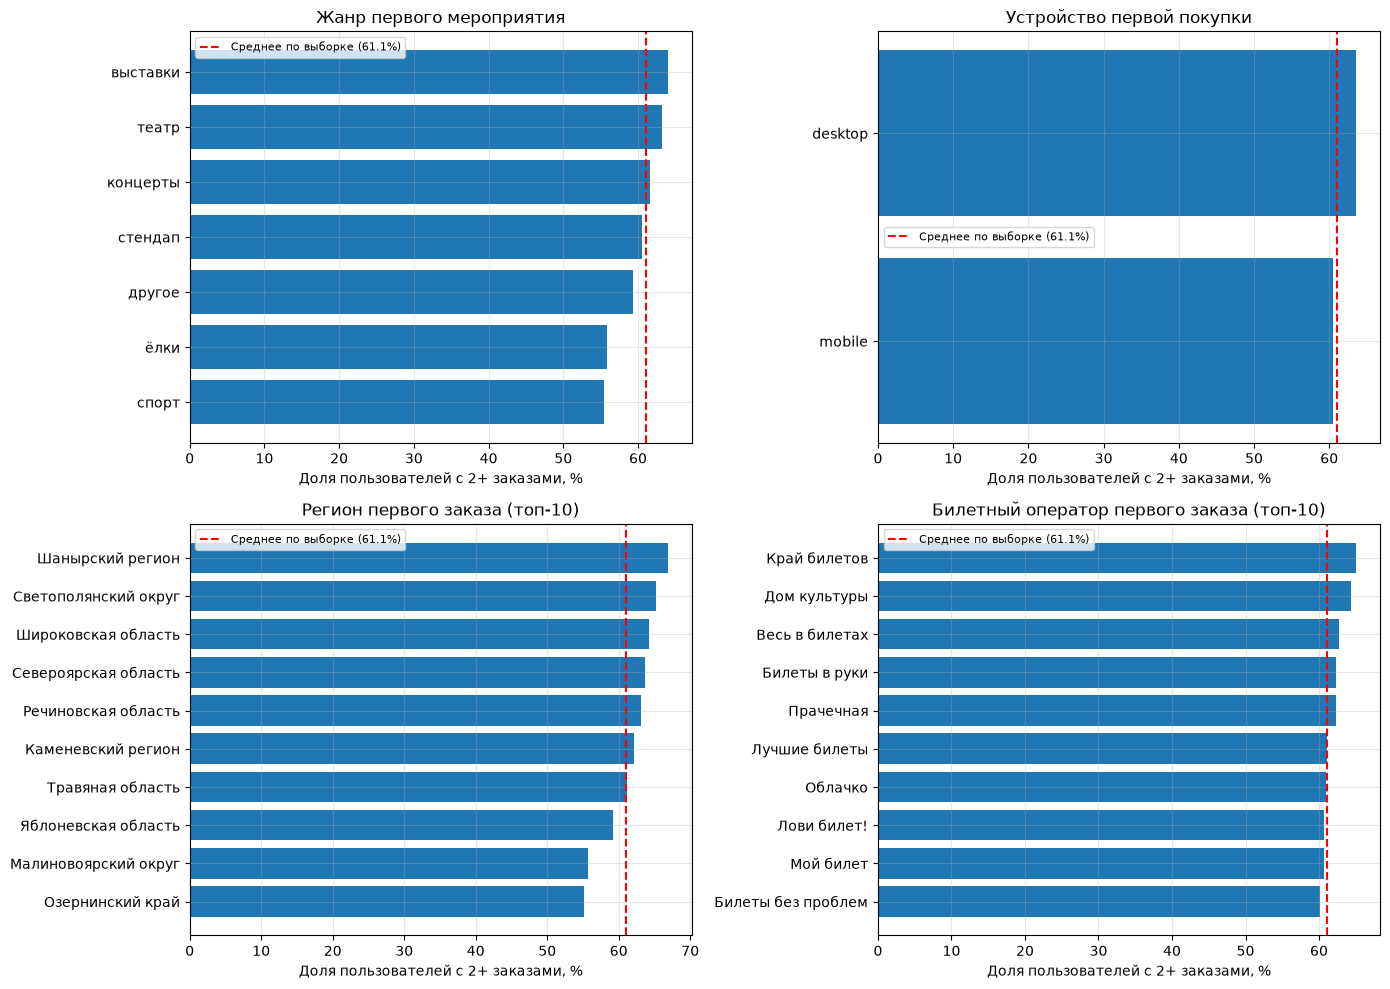

In [67]:
fig, axes = plt.subplots(2, 2, figsize = (14, 10))

datasets = [
    (genre_return, axes[0, 0], 'Жанр первого мероприятия'),
    (device_return, axes[0, 1], 'Устройство первой покупки'),
    (region_return, axes[1, 0], 'Регион первого заказа (топ-10)'),
    (service_return, axes[1, 1], 'Билетный оператор первого заказа (топ-10)'),
]

for data, ax, title in datasets:
    # Сортируем по доле возврата для наглядности
    data_sorted = data.sort_values('return_rate')
    ax.barh(data_sorted.index, data_sorted['return_rate'] * 100)
    ax.axvline(overall_return_rate * 100, color = 'red', linestyle = '--', 
               label = f'Среднее по выборке ({overall_return_rate:.1%})')
    ax.set_title(title)
    ax.set_xlabel('Доля пользователей с 2+ заказами, %')
    ax.legend(fontsize = 8)
    ax.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

- Устройство и билетный оператор дают наиболее надёжные и интерпретируемые сигналы — большие сегменты, умеренный и понятный разброс.
- Регион — самый вариативный признак.
- Ни в одном признаке нет сегмента, который был бы аномально лучше/хуже остальных на порядок. Все различия в диапазоне 3–12 п.п., что говорит о том, что признаки первого заказа сами по себе не являются сильными предсказателями возврата. Они дают сигнал.
- Самые крупные "точки входа" (`mobile`, `концерты`, `Каменевский регион`, `Билеты без проблем`, то есть самые массовые сегменты по каждому признаку) почти везде показывают возврат на уровне среднего или чуть ниже, что логично, ведь они и формируют это среднее, но также показывают, что масштаб входа не гарантирует лучшую лояльность.

**Проверим продуктовые гипотезы:**

- **Гипотеза 1.**

Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.

Это гипотеза именно про сравнение двух конкретных категорий из `first_genre` — «спорт» и «концерты». У нас эти данные уже есть в `genre_return`.

In [68]:
# Достаём долю возврата для двух конкретных сегментов из уже посчитанной таблицы
sport_rate = genre_return.loc['спорт', 'return_rate_%']
concert_rate = genre_return.loc['концерты', 'return_rate_%']

sport_n = genre_return.loc['спорт', 'users_count']
concert_n = genre_return.loc['концерты', 'users_count']

print(f'Спорт: {sport_rate}% возврата (n = {sport_n})')
print(f'Концерты: {concert_rate}% возврата (n = {concert_n})')
print(f'Разница: {sport_rate - concert_rate:.2f} п.п.')

Спорт: 55.46% возврата (n = 788)
Концерты: 61.54% возврата (n = 9495)
Разница: -6.08 п.п.


**Гипотеза 1 не подтверждается** — данные показывают обратную картину. Доля возврата у пользователей, впервые пришедших на концерты (61.54%), заметно выше, чем у пришедших на спорт (55.46%) — разница около 6 процентных пунктов не в пользу гипотезы. При этом важно оговорить размеры групп: концерты — самый крупный сегмент (9495 человек), это очень надёжная оценка; спорт — заметно меньше (788 человек), но это уже не «десятки», а несколько сотен, так что для 6 п.п. разницы такая выборка вполне достаточна, чтобы не списывать различие на случайность.

- **Гипотеза 2.**

В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

Это гипотеза про общую закономерность между размером региона и долей возврата, то есть по сути мы проверяем, есть ли между этими двумя величинами корреляция, и в какую сторону.

In [69]:
# Корреляция между размером региона и долей возврата (в топ-10)
correlation_top10 = region_return['users_count'].corr(region_return['return_rate'])
print(f'Корреляция между размером региона и долей возврата (топ-10): {correlation_top10:.3f}')

Корреляция между размером региона и долей возврата (топ-10): 0.134


Наблюдается слабая положительная корреляция (< 0.3). Размер региона почти никак не объясняет разброс в доле возврата.

Наглядно сопоставим ранг региона по размеру с рангом по доле возврата:

In [70]:
region_rank = region_return.copy()
region_rank['rank_by_size'] = region_rank['users_count'].rank(ascending = False).astype(int)
region_rank['rank_by_return'] = region_rank['return_rate'].rank(ascending = False).astype(int)

display(region_rank[['users_count', 'return_rate_%', 'rank_by_size', 'rank_by_return']])

,users_count,return_rate_%,rank_by_size,rank_by_return
first_region,,,,
Каменевский регион,7040,62.14,1,6
Североярская область,3748,63.63,2,4
Широковская область,1216,64.23,3,3
Озернинский край,674,55.19,4,10
Малиновоярский округ,524,55.73,5,9
Шанырский регион,495,66.87,6,1
Травяная область,484,61.16,7,7
Светополянский округ,451,65.19,8,2
Речиновская область,437,63.16,9,5


- `Каменевский регион` — 1-е место по размеру, но лишь 6-е по доле возврата.
- `Шанырский регион` — лидер по возврату (1-е место), но по размеру только 6-й.
- `Озернинский край` — 4-й по размеру, но последний (10-й) по возврату, то есть довольно крупный регион с одной из худших долей.
- Единственное более-менее согласованное совпадение — `Широковская область` (3-е место и там, и там).

**Гипотеза 2 не подтверждается.** Внутри топ-10 регионов по числу пользователей корреляция между размером региона и долей повторных заказов практически отсутствует (0.134 < 0.3 — слабая положительная связь).

Признаки первого заказа (жанр, устройство, регион, оператор) в отдельности являются слабыми предикторами повторной покупки — они дают статистически заметные, но не сильные различия между сегментами, и популярность/размер сегмента сам по себе не гарантирует более высокую лояльность.

---

### Исследование поведения пользователей через показатели выручки и состава заказа
Изучим количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

1. Проследим связь между средней выручкой сервиса с заказа и повторными заказами. Для этого построим сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):

In [71]:
one_order = user_profile[user_profile['is_two'] == False]
two_plus_orders = user_profile[user_profile['is_two'] == True]

print('Пользователи с 1 заказом:')
print(one_order['avg_revenue_rub'].describe())
print()
print('Пользователи с 2+ заказами:')
print(two_plus_orders['avg_revenue_rub'].describe())

Пользователи с 1 заказом:
count    8363.000000
mean      545.774764
std       519.402525
min         0.000000
25%       133.055000
50%       378.870000
75%       830.975000
max      2628.421739
Name: avg_revenue_rub, dtype: float64

Пользователи с 2+ заказами:
count    13123.000000
mean       545.690788
std        370.785638
min          0.000000
25%        269.741501
50%        495.756000
75%        748.860833
max       2628.421739
Name: avg_revenue_rub, dtype: float64


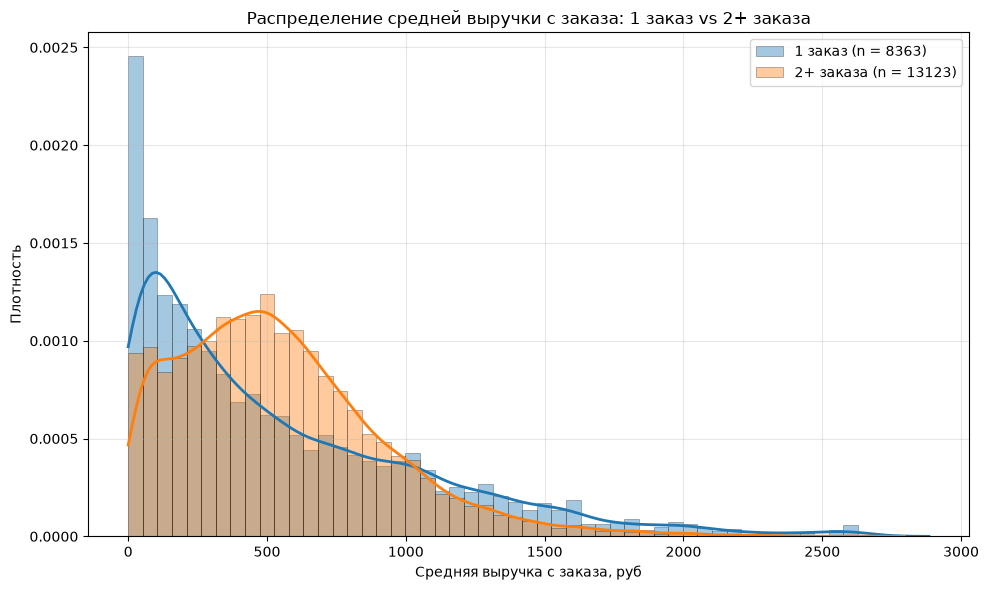

In [72]:
# Общий диапазон по обеим группам, чтобы bins были одинаковыми
combined = pd.concat([one_order['avg_revenue_rub'], two_plus_orders['avg_revenue_rub']])
value_range = (combined.min(), combined.max())

fig, ax = plt.subplots(figsize = (10, 6))

# Гистограммы
ax.hist(one_order['avg_revenue_rub'], bins = 50, range = value_range, 
        density = True, alpha = 0.4, edgecolor = 'black', linewidth = 0.5,
        label = f'1 заказ (n = {len(one_order)})', color = 'tab:blue')
ax.hist(two_plus_orders['avg_revenue_rub'], bins = 50, range = value_range, 
        density = True, alpha = 0.4, edgecolor = 'black', linewidth = 0.5,
        label = f'2+ заказа (n = {len(two_plus_orders)})', color = 'tab:orange')

# KDE поверх гистограмм
sns.kdeplot(one_order['avg_revenue_rub'], ax = ax, color = 'tab:blue', linewidth = 2, clip = (0, None))
sns.kdeplot(two_plus_orders['avg_revenue_rub'], ax = ax, color = 'tab:orange', linewidth = 2, clip = (0, None))

ax.set_title('Распределение средней выручки с заказа: 1 заказ vs 2+ заказа')
ax.set_xlabel('Средняя выручка с заказа, руб')
ax.set_ylabel('Плотность')
ax.legend()
ax.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

- **Пользователи с 1 заказом** концентрируются в основном в низком ценовом диапазоне — пик распределения приходится на значения, близкие к нулю, после чего идёт плавный спад. Такая скошенная форма означает, что типичный (самый частый) заказ в этой группе дешёвый, а среднее вытгивается вверх редкими дорогими покупками.
- **Вернувшиеся пользователи (2+ заказа)** концентрируются в диапазоне 300–800 руб — пик их распределения заметно смещён вправо относительно одноразовых покупателей. Выручка с заказа здесь более однородная и предсказуемая.

Дешёвые первые заказы могут быть признаком пользователей пробующих сервис на незначительной покупке и не возвращающихся впоследствии. У вернувшихся пользователей типичный заказ ощутимо дороже. То есть более весомая по стоимости первая покупка может быть связана с более высокой вероятностью возврата.

2. Сравним распределение по средней выручке с заказа в двух группах пользователей:

Сначала смотрим `describe()` по обеим группам:

In [73]:
orders_2_4 = user_profile[(user_profile['is_two'] == True) & (user_profile['is_five'] == False)]
orders_5_plus = user_profile[user_profile['is_five'] == True]

print('Пользователи с 2–4 заказами:')
print(orders_2_4['avg_revenue_rub'].describe())
print()
print('Пользователи с 5+ заказами:')
print(orders_5_plus['avg_revenue_rub'].describe())

Пользователи с 2–4 заказами:
count    7143.000000
mean      552.318951
std       420.136847
min         0.000000
25%       219.565000
50%       472.470000
75%       799.257500
max      2628.421739
Name: avg_revenue_rub, dtype: float64

Пользователи с 5+ заказами:
count    5980.000000
mean      537.773569
std       301.271237
min         0.000000
25%       329.272750
50%       513.309000
75%       705.734981
max      2299.869022
Name: avg_revenue_rub, dtype: float64


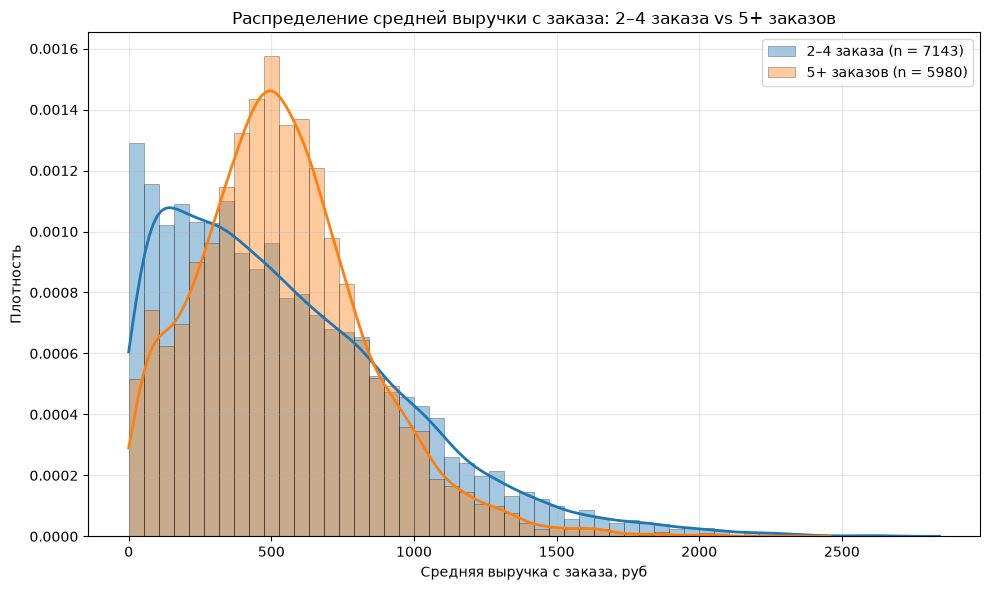

In [74]:
# Общий диапазон по обеим группам для единой сетки bins
combined_2groups = pd.concat([orders_2_4['avg_revenue_rub'], orders_5_plus['avg_revenue_rub']])
value_range_2groups = (combined_2groups.min(), combined_2groups.max())

fig, ax = plt.subplots(figsize = (10, 6))

# Гистограммы
ax.hist(orders_2_4['avg_revenue_rub'], bins = 50, range = value_range_2groups, 
        density = True, alpha = 0.4, edgecolor = 'black', linewidth = 0.5,
        label = f'2–4 заказа (n = {len(orders_2_4)})', color = 'tab:blue')
ax.hist(orders_5_plus['avg_revenue_rub'], bins = 50, range = value_range_2groups, 
        density = True, alpha = 0.4, edgecolor = 'black', linewidth = 0.5,
        label = f'5+ заказов (n = {len(orders_5_plus)})', color = 'tab:orange')

# KDE поверх гистограмм — сглаженная форма распределения
sns.kdeplot(orders_2_4['avg_revenue_rub'], ax = ax, color = 'tab:blue', linewidth = 2, clip = (0, None))
sns.kdeplot(orders_5_plus['avg_revenue_rub'], ax = ax, color = 'tab:orange', linewidth = 2, clip = (0, None))

ax.set_title('Распределение средней выручки с заказа: 2–4 заказа vs 5+ заказов')
ax.set_xlabel('Средняя выручка с заказа, руб')
ax.set_ylabel('Плотность')
ax.legend()
ax.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

**Группа 2–4 заказа** имеет менее выраженный пик (около 300–350 руб) и заметно более широкое, растянутое основание с длинным хвостом вплоть до 2500+ руб. Форма скошена вправо, обычно покупки недорогие, но встречается заметная доля дорогих заказов, которые поднимают среднее значение.

**Группа 5+ заказов** имеет выраженный узкий пик около 500 руб — самый высокий столбец на графике — и заметно более компактную, симметричную форму с более коротким хвостом. Распределение сжато вокруг среднего значения сильнее, чем у синей группы.

Есть ли различия по значению средней выручки с заказа между пользователями этих двух групп? - Значения `mean` практически совпадают — 552 против 538 руб), сильного различия нет. Заметна разница формы и разброса распределения: у группы "5+ заказов" средний чек более стабильный и предсказуемый (пик выше и уже, `std` ниже), тогда как у группы "2–4 заказа" распределение более растянутое и скошенное вправо за счёт длинного хвоста дорогих заказов.

Сумма выручки с заказа сама по себе слабо различает эти две группы по среднему уровню — высокая частота заказов не связана с тем, что пользователь тратит на заказ больше или меньше. Однако форма распределения показывает устойчивую закономерность: чем выше лояльность пользователя, тем однороднее и предсказуемее его средний чек.

3. Проанализируем влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучим распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`)

In [75]:
print('Статистика по avg_tickets_count:')
print(user_profile['avg_tickets_count'].describe())

Статистика по avg_tickets_count:
count    21486.000000
mean         2.744528
std          0.920247
min          1.000000
25%          2.000000
50%          2.750000
75%          3.111111
max         11.000000
Name: avg_tickets_count, dtype: float64


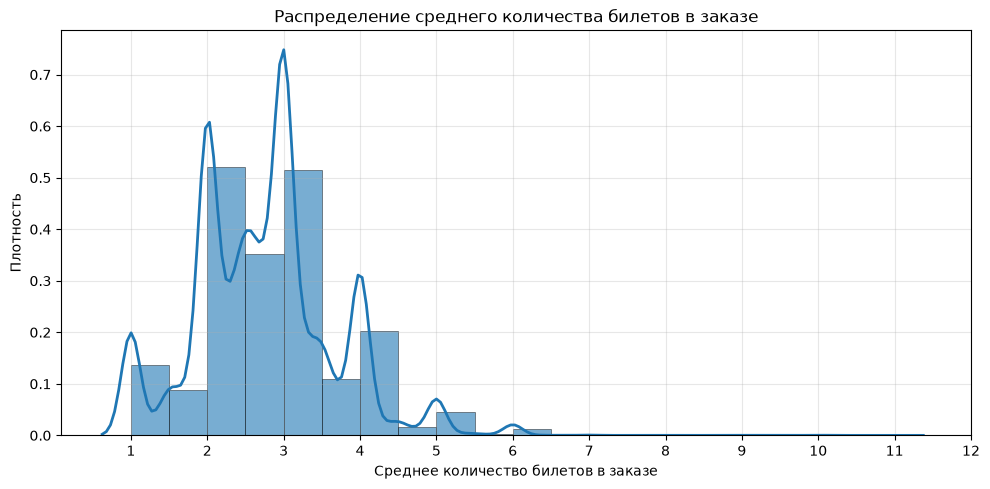

In [76]:
fig, ax = plt.subplots(figsize=(10, 5))

# Гистограммы
ax.hist(user_profile['avg_tickets_count'], bins = 20, density = True, 
        edgecolor = 'black', linewidth = 0.5, alpha = 0.6, color = 'tab:blue')

# KDE поверх гистограмм
sns.kdeplot(user_profile['avg_tickets_count'], ax = ax, color = 'tab:blue', linewidth = 2, clip = (0, None))

ax.set_title('Распределение среднего количества билетов в заказе')
ax.set_xlabel('Среднее количество билетов в заказе')
ax.set_ylabel('Плотность')
ax.set_xticks(range(1, int(user_profile['avg_tickets_count'].max()) + 2))
ax.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

На графике отчётливо видно несколько отдельных пиков: главный, самый высокий — на 3 билетах, второй по высоте — на 2, третий — на 4, и небольшой всплеск у 1. После 5 билетов распределение плавно перетекает в хвост. Подавляющее большинство пользователей покупают в среднем 2–4 билета за заказ. Заказы на 5+ билетов уже редкость, а на 8–11 билетов — единичные случаи.

- Разделим пользователей на несколько сегментов по среднему количеству билетов в заказе:
  - от 1 до 2 билетов;
  - от 2 до 3 билетов;
  - от 3 до 5 билетов;
  - от 5 и более билетов.

Разделим пользователей на 4 сегмента по среднему количеству билетов в заказе, используя `pd.cut()`.

In [77]:
bins = [1, 2, 3, 5, float('inf')]
labels = ['1–2 билета', '2–3 билета', '3–5 билетов', '5+ билетов']

user_profile['tickets_segment'] = pd.cut(
    user_profile['avg_tickets_count'],
    bins=bins,
    labels=labels,
    right=False
)

user_profile[['avg_tickets_count', 'tickets_segment']].head(10)

,avg_tickets_count,tickets_segment
0,4.000000,3–5 билетов
1,3.000000,3–5 билетов
2,2.666667,2–3 билета
3,4.000000,3–5 билетов
4,1.500000,1–2 билета
5,3.307692,3–5 билетов
6,1.500000,1–2 билета
7,3.000000,3–5 билетов
8,4.000000,3–5 билетов
9,1.333333,1–2 билета


Проверим целостность полученной сегментации: сравним общее число пользователей с числом пользователей, которым присвоен сегмент — если бы значения не попадали ни в один интервал, там образовался бы пропуск (NaN). Также посмотрим, сколько пользователей попало в каждый сегмент, чтобы оценить равномерность распределения.

In [78]:
print(f'Всего пользователей: {len(user_profile)}')
print(f'Распределено по сегментам: {user_profile["tickets_segment"].notna().sum()}')
print()
print(user_profile['tickets_segment'].value_counts().sort_index())

Всего пользователей: 21486
Распределено по сегментам: 21486

tickets_segment
1–2 билета     2410
2–3 билета     9356
3–5 билетов    9059
5+ билетов      661
Name: count, dtype: int64


Пользователи распределены по сегментам среднего количества билетов неравномерно: средние сегменты (2–3 и 3–5) самые крупные, они вместе содержат больше 85% всех пользователей, что логично согласуется с гистограммой. Там главные пики как раз были на 2, 3 и 4 билетах. Крайние сегменты заметно меньше: 1–2 билета — 2410 человек, а 5+ билетов — самый малочисленный сегмент, всего 661 человек (около 3% выборки), что логично для нетипично крупных групповых заказов. Проверка на целостность подтвердила, что все 21486 пользователей корректно распределены по сегментам без потерь.

- Для каждого сегмента подсчитаем общее число пользователей и долю пользователей, совершивших повторные заказы.

In [79]:
tickets_return = segment_return_rate(user_profile, 'tickets_segment')
display(tickets_return)

,users_count,return_rate,share_of_total,return_rate_%,share_of_total_%
tickets_segment,,,,,
2–3 билета,9356,0.731937,0.435446,73.19,43.54
3–5 билетов,9059,0.542665,0.421623,54.27,42.16
1–2 билета,2410,0.512448,0.112166,51.24,11.22
5+ билетов,661,0.187595,0.030764,18.76,3.08


Ответим на вопросы:
- Как распределены пользователи по сегментам — равномерно или сконцентрировано? - Распределение выраженно неравномерное. Основная масса пользователей сосредоточена в двух средних сегментах: `2–3 билета` (9356 чел., 43.54%) и `3–5 билетов` (9059 чел., 42.16%) — вместе они составляют почти 86% всей выборки. Крайние сегменты малочисленны: `1–2 билета` — 2410 человек (11.22%), а `5+ билетов` — самый редкий сегмент, всего 661 человек (3.08%). То есть подавляющее большинство пользователей заказывают в среднем 2–5 билетов за раз, а заказы на 1–2 или 5+ билетов — сравнительно нетипичное поведение.
- Есть ли сегменты с аномально высокой или низкой долей повторных покупок? - Да, и разброс здесь внушительный — от 18.76% до 73.19% (почти в 4 раза), при среднем по выборке 61.08%:

В отличие от признаков первого заказа (жанр, устройство, регион, оператор), которые давали слабый сигнал, среднее количество билетов в заказе — гораздо более сильный и информативный предиктор возврата пользователя, и на него стоит обратить особое внимание в итоговых рекомендациях для бизнеса

---

### Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучим временные параметры, связанные с первым заказом пользователей:
- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

Добавим в `user_profile` столбец дней недели первой покупки:

In [80]:
# Словарь для перевода номера дня недели
dow_names = {
    0: 'Понедельник',
    1: 'Вторник',
    2: 'Среда',
    3: 'Четверг',
    4: 'Пятница',
    5: 'Суббота',
    6: 'Воскресенье'
}

# Извлекаем день недели первой покупки
user_profile['first_order_dow'] = (
    pd.to_datetime(user_profile['first_order_date'])
    .dt.dayofweek
    .map(dow_names)
)

user_profile[['first_order_date', 'first_order_dow']].head(10)

,first_order_date,first_order_dow
0,2024-08-20,Вторник
1,2024-07-23,Вторник
2,2024-07-13,Суббота
3,2024-08-15,Четверг
4,2024-09-29,Воскресенье
5,2024-06-20,Четверг
6,2024-06-25,Вторник
7,2024-07-25,Четверг
8,2024-06-17,Понедельник
9,2024-07-04,Четверг


Добавим в `user_profile` столбец лайфтайма

In [81]:
# Считаем лайфтайм пользователя — время от первой до последней покупки, в днях
user_profile['lifetime_days'] = (
    pd.to_datetime(user_profile['last_order_date']) 
    - pd.to_datetime(user_profile['first_order_date'])
).dt.days

user_profile[['first_order_date', 'last_order_date', 'lifetime_days']].head(10)

,first_order_date,last_order_date,lifetime_days
0,2024-08-20,2024-08-20,0
1,2024-07-23,2024-10-06,75
2,2024-07-13,2024-10-23,102
3,2024-08-15,2024-08-15,0
4,2024-09-29,2024-10-15,16
5,2024-06-20,2024-06-21,1
6,2024-06-25,2024-06-25,0
7,2024-07-25,2024-07-25,0
8,2024-06-17,2024-06-17,0
9,2024-07-04,2024-09-29,87


Посмотрим на распределение лайфтайма по всей выборке:

In [82]:
user_profile['lifetime_days'].describe()

count    21486.000000
mean        37.607884
std         51.036437
min          0.000000
25%          0.000000
50%          0.000000
75%         77.000000
max        152.000000
Name: lifetime_days, dtype: float64

Медиана и 25-й перцентиль равны 0. Это значит, что больше половины пользователей имеют лайфтайм = 0, то есть сделали только одну покупку. Среднее (37.6) заметно выше медианы — признак смещённого вправо распределения: основная масса в нуле, но у части пользователей лайфтайм растягивается вплоть до 152 дней.

Стоит сверить долю нулевых лайфтаймов с долей is_two == 0, чтобы убедиться, что это одни и те же пользователи (проверка целостности):

In [83]:
# Проверяем, что нулевой лайфтайм соответствует пользователям с одной покупкой (is_two == 0)
print(f"Доля пользователей с lifetime_days == 0: {(user_profile['lifetime_days'] == 0).mean():.4f}")
print(f"Доля пользователей с is_two == 0: {(user_profile['is_two'] == 0).mean():.4f}")

Доля пользователей с lifetime_days == 0: 0.5157
Доля пользователей с is_two == 0: 0.3892


Доли не совпали: 51.57% с нулевым лайфтаймом против 38.92% с is_two == 0. Разница почти в 13 процентных пунктов — это не случайный шум, стоит разобраться, откуда она берётся, прежде чем двигаться дальше.

Дело может быть в том, что `first_order_date` и `last_order_date` — это даты (без времени). Значит, если пользователь сделал 2 и более заказов в один и тот же день (например, купил билеты на два разных мероприятия утром и вечером одной даты), то `is_two = 1` (у него 2+ заказов, это видно по `order_id`), но `first_order_date == last_order_date`, следовательно `lifetime_days = 0`. Чтобы это проверить, посмотрим на пользователей, у которых `lifetime_days == 0`, но `is_two == 1`.

In [84]:
# Проверяем пользователей с нулевым лайфтаймом, но с 2+ заказами
same_day_multi = user_profile[(user_profile['lifetime_days'] == 0) & (user_profile['is_two'] == 1)]
print(f"Количество таких пользователей: {len(same_day_multi)}")
same_day_multi[['total_orders', 'avg_days_between']].describe()

Количество таких пользователей: 2718


,total_orders,avg_days_between
count,2718.000000,2718.000000
mean,2.994481,0.047952
std,2.478685,1.607250
min,2.000000,0.000000
25%,2.000000,0.000000
50%,2.000000,0.000000
75%,3.000000,0.000000
max,73.000000,64.000000


2718 пользователей / 21486 = 12.65%, и это точно закрывает разрыв, который мы видели (51.57% − 38.92% = 12.65 п.п.). Значит заметная часть вернувшихся по `is_two` пользователей на самом деле сделала все заказы в рамках одного календарного дня, и поэтому лайфтайм у них 0.

Средний интервал между покупками пользователей с повторными заказами

In [85]:
# Смотрим распределение avg_days_between только у вернувшихся пользователей (is_two == 1)
user_profile.loc[user_profile['is_two'] == 1, 'avg_days_between'].describe()

count    13123.000000
mean        16.214124
std         22.371082
min          0.000000
25%          1.530612
50%          8.529412
75%         21.000000
max        148.000000
Name: avg_days_between, dtype: float64

- `count = 13123`, что совпадает с числом пользователей `is_two == 1` — целостность подтверждена.
- Распределение сильно скошено вправо: медиана 8.5 дня заметно ниже среднего (16.2) — то есть у большинства вернувшихся интервал между покупками небольшой, но хвост тянет среднее вверх.

Все три параметра изучены и готовы для дальнейшего анализа.

**1. Проанализируем, как день недели, в который была совершена первая покупка, влияет на поведение пользователей.**

Для каждого дня недели подсчитаем общее число пользователей и долю пользователей, совершивших повторные заказы.

In [86]:
# Считаем число пользователей и долю повторных заказов по дню недели первой покупки
dow_return = segment_return_rate(user_profile, 'first_order_dow')

# Порядок дней недели для сортировки (пн -> вс)
dow_order = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']

# Восстанавливаем логичный порядок дней недели (пн -> вс)
dow_return = dow_return.reindex(dow_order)

display(dow_return)

,users_count,return_rate,share_of_total,return_rate_%,share_of_total_%
first_order_dow,,,,,
Понедельник,2893,0.626685,0.134646,62.67,13.46
Вторник,3158,0.616846,0.146979,61.68,14.70
Среда,3053,0.621684,0.142093,62.17,14.21
Четверг,3106,0.593690,0.144559,59.37,14.46
Пятница,3248,0.596675,0.151168,59.67,15.12
Суббота,3278,0.622636,0.152564,62.26,15.26
Воскресенье,2750,0.596727,0.127990,59.67,12.80


Визуализируем используя столбчатую диаграмму с горизонтальной линией среднего значения по всей выборке:

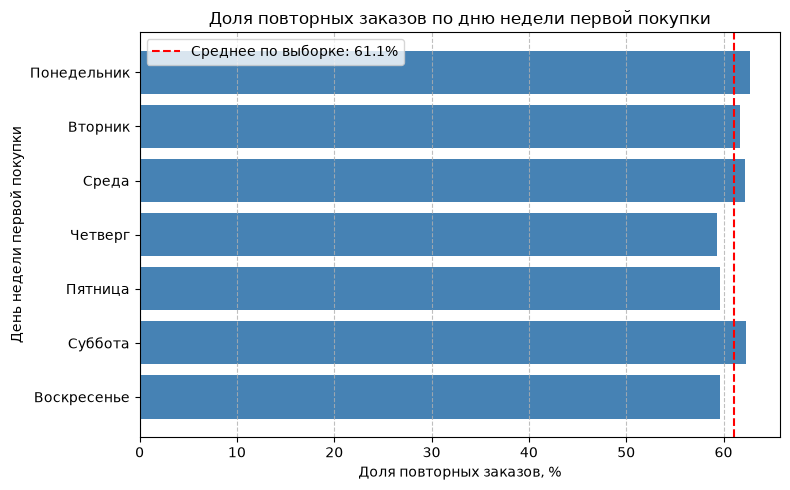

In [87]:
# Визуализируем долю повторных заказов по дню недели первой покупки (горизонтальный barplot)
mean_return_rate = user_profile['is_two'].mean() * 100
dow_return_plot = dow_return.iloc[::-1] 

fig, ax = plt.subplots(figsize = (8, 5))
ax.barh(dow_return_plot.index, dow_return_plot['return_rate_%'], color = 'steelblue')
ax.axvline(mean_return_rate, color = 'red', linestyle = '--', label = f'Среднее по выборке: {mean_return_rate:.1f}%')
ax.grid(axis = 'x', linestyle = '--', alpha = 0.8, zorder = 0)

ax.set_title('Доля повторных заказов по дню недели первой покупки')
ax.set_xlabel('Доля повторных заказов, %')
ax.set_ylabel('День недели первой покупки')
ax.legend()
plt.tight_layout()
plt.show()

День недели первой покупки практически не влияет на вероятность возврата клиента.

Разброс значений минимальный — от 59.37% (четверг) до 62.67% (понедельник), то есть всего около 3.3 процентных пункта между крайними значениями. Все семь дней колеблются вокруг общего среднего по выборке (61.1%), без явных выбросов в ту или иную сторону. Можно заметить лёгкую тенденцию: понедельник, среда и суббота показывают чуть более высокую долю возврата (~62%), а четверг, пятница и воскресенье — чуть ниже (~59.5–59.7%). Но при такой узкой амплитуде колебаний это, скорее всего, находится в пределах случайной вариации, а не отражает закономерность в поведении пользователей.

День недели первой покупки — слабый признак возврата.

**2. Изучим, как средний интервал между заказами влияет на удержание клиентов.**

Рассчитаем среднее время между заказами для двух групп пользователей:
- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

In [88]:
# Разбиваем вернувшихся пользователей на две группы по числу заказов и считаем средний интервал между покупками
group_2_4 = user_profile.loc[(user_profile['is_two'] == 1) & (user_profile['is_five'] == 0), 'avg_days_between']
group_5plus = user_profile.loc[user_profile['is_five'] == 1, 'avg_days_between']

print('Группа 2–4 заказа:')
print(group_2_4.describe())
print()
print('Группа 5+ заказов:')
print(group_5plus.describe())

Группа 2–4 заказа:
count    7143.000000
mean       21.328678
std        28.485070
min         0.000000
25%         0.000000
50%         9.000000
75%        34.000000
max       148.000000
Name: avg_days_between, dtype: float64

Группа 5+ заказов:
count    5980.000000
mean       10.104882
std         7.781628
min         0.000000
25%         4.138889
50%         8.375000
75%        14.285714
max        37.500000
Name: avg_days_between, dtype: float64


- Медианы близки (9 против 8.38 дня), средний пользователь в обеих группах делает заказы с похожей частотой.
- Среднее и разброс различаются: в `группе 2–4 заказа` среднее (21.3) вдвое выше медианы — это явный признак сильно ссмещённого вправо распределения с длинным хвостом (max = 148 дней, std = 28.5). В `группе 5+` разброс гораздо компактнее (std = 7.78, max = 37.5), среднее ближе к медиане.

Исследуем, как средний интервал между заказами влияет на вероятность повторного заказа

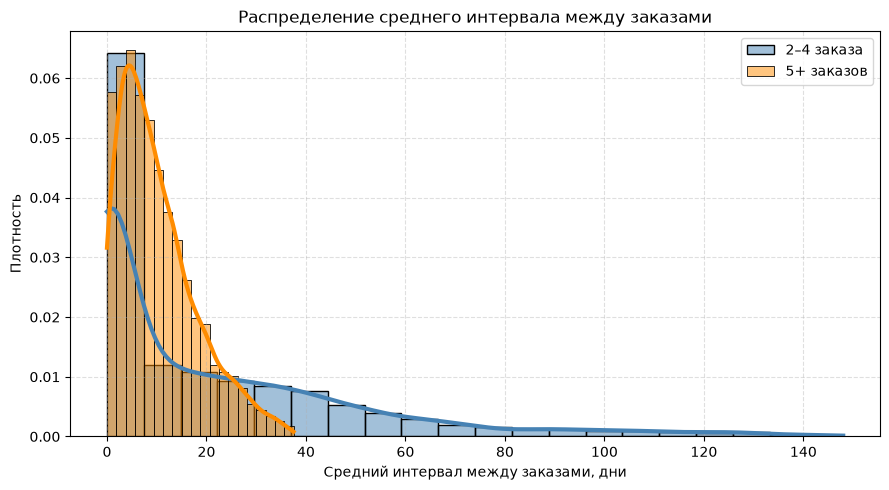

In [89]:
# Сравниваем распределение среднего интервала между заказами в двух группах пользователей
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(group_2_4, bins = 20, stat = 'density', alpha = 0.5, kde = True,
             color = 'steelblue', edgecolor = 'black', label = '2–4 заказа', ax=ax,
             line_kws = {'color': 'navy', 'linewidth': 3})
sns.histplot(group_5plus, bins = 20, stat = 'density', alpha = 0.5, kde = True,
             color = 'darkorange', edgecolor = 'black', label = '5+ заказов', ax = ax,
             line_kws = {'color': 'saddlebrown', 'linewidth': 3})

ax.set_title('Распределение среднего интервала между заказами')
ax.set_xlabel('Средний интервал между заказами, дни')
ax.set_ylabel('Плотность')
ax.grid(axis = 'both', linestyle = '--', alpha = 0.4, zorder = 0)
ax.legend()
plt.tight_layout()
plt.show()


- Оба распределения имеют пик в районе 0–10 дней. Этот примерно одинаковый интервал между заказами (медианы близки: 9 дней vs 8.4 дня) характерен и для тех, кто вернулся дважды-четырежды, и для постоянных клиентов.
- Ключевое различие наблюдается в форме хвоста. У группы `5+ заказов` распределение компактное: KDE-кривая резко спадает к нулю уже после 30–40 дней, максимум в группе — 37.5 дня. У группы `2–4 заказа` — выраженный длинный правый хвост, растянутый вплоть до 148 дней, из-за чего среднее (21.3) вдвое превышает медиану.

У пользователей, которые совершают заказы регулярно и без больших пауз (интервал стабильно укладывается в 30–40 дней), гораздо выше шанс продолжить возвращаться и накопить 5+ заказов. А наличие даже одного длинного перерыва между покупками (30+, тем более 60–150 дней) — признак пользователя, который, скорее всего, ограничится 2–4 заказами и не станет постоянным.

Из трёх временных характеристик практическую ценность для прогнозирования удержания несёт в первую очередь регулярность покупок (короткие, стабильные интервалы между заказами), а не то, в какой день недели пользователь пришёл впервые. Это согласуется с более ранним наблюдением по признакам первого заказа (жанр, устройство, регион) — они тоже давали слабый сигнал по сравнению с поведенческими метриками (среднее число билетов, регулярность заказов).

### Корреляционный анализ количества покупок и признаков пользователя
Изучим, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используем универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

**1. Проведём корреляционный анализ**

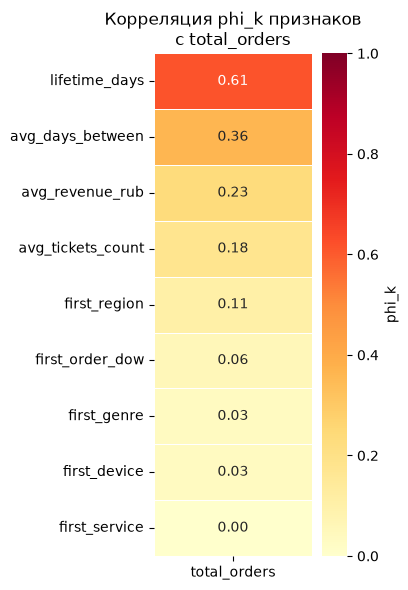

In [90]:
# Формируем подвыборку признаков для корреляционного анализа phi_k
phik_columns = [
    'first_device', 'first_region', 'first_service', 'first_genre', 'first_order_dow',
    'total_orders', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_between', 'lifetime_days'
]

# Числовые непрерывные признаки, которые phik должен трактовать как интервальные, а не категориальные
interval_cols = ['total_orders', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_between', 'lifetime_days']

# Убираем строки с пропуском в avg_days_between (пользователи с одной покупкой)
phik_df = user_profile[phik_columns].dropna(subset = ['avg_days_between'])

# Считаем полную матрицу корреляции phi_k (функция считает все пары признаков сразу)
phik_corr = phik_matrix(phik_df, interval_cols = interval_cols)

# Извлекаем именно связь каждого признака с total_orders и сортируем по убыванию силы связи
total_orders_corr = phik_corr['total_orders'].drop('total_orders').sort_values(ascending = False).to_frame()

# Визуализируем теплокартой
fig, ax = plt.subplots(figsize = (4, 6))
sns.heatmap(total_orders_corr, annot = True, fmt = '.2f', cmap = 'YlOrRd', vmin = 0, vmax = 1,
            linewidths = 0.5, cbar_kws = {'label': 'phi_k'}, ax = ax)
ax.set_title('Корреляция phi_k признаков\nс total_orders')
ax.set_xticklabels(['total_orders'])
plt.tight_layout()
plt.show()

- `lifetime_days` (0.61) — самая сильная связь: чем дольше пользователь активен на платформе, тем физически больше шансов накопить заказы. Тут стоит держать в уме, что связь отчасти механическая (не совсем причинно-следственная в чистом виде) — чем больше заказов, тем шире по определению временное окно между первым и последним из них.
- `avg_days_between` (0.36) — вторая по силе, подтверждает выводы по предшествующему анализу: регулярность покупок (короткие интервалы) действительно связана с числом заказов.
- `avg_revenue_rub` (0.23) и `avg_tickets_count` (0.18) — умеренная связь, тоже ожидаемо.
- `first_region` (0.11), `first_order_dow` (0.06), `first_genre` (0.03), `irst_device` (0.03), `first_service` (0.00) — все признаки первого заказа показывают слабую либо почти нулевую связь с числом заказов.

Характеристики первого касания (жанр, устройство, регион, оператор, день недели) почти не связаны с количеством последующих заказов — это полностью подтверждает то, что мы наблюдали на всех предыдущих этапах анализа отдельными кусками, а сейчас видим сведённым в одну картину. Единственный признак первого заказа с хоть какой-то заметной связью — регион (0.11), но и он далеко не сильный.

Значимо связаны с числом заказов только поведенческие метрики после первого заказа — то, как часто и стабильно пользователь возвращается, а не то, откуда и с чего он начал.

Выделите сегменты пользователей по полю `total_orders` и повторим корреляционный анализ. Выделим такие сегменты:
- от 2 до 4 заказов;
- от 5 и выше.

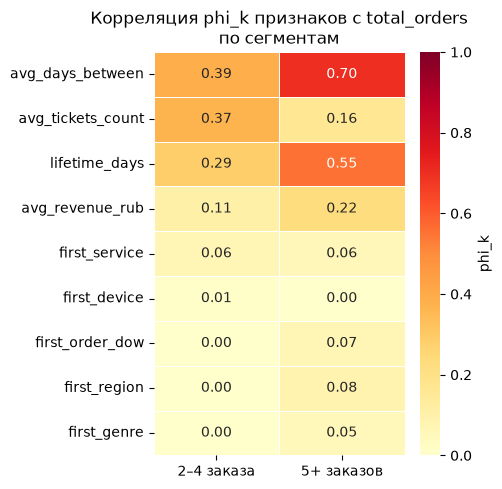

In [91]:
# Сегментируем пользователей по total_orders (сегмент "1 заказ" пропускаем — там total_orders константа)
segment_2_4 = user_profile[(user_profile['total_orders'] >= 2) & (user_profile['total_orders'] <= 4)]
segment_5plus = user_profile[user_profile['total_orders'] >= 5]

def calc_total_orders_corr(segment_df, columns, interval_cols):
    """Считает phi_k каждого признака с total_orders для заданного сегмента пользователей."""
    segment_phik_df = segment_df[columns].dropna(subset = ['avg_days_between'])
    segment_corr = phik_matrix(segment_phik_df, interval_cols = interval_cols)
    return segment_corr['total_orders'].drop('total_orders')

corr_2_4 = calc_total_orders_corr(segment_2_4, phik_columns, interval_cols)
corr_5plus = calc_total_orders_corr(segment_5plus, phik_columns, interval_cols)

# Объединяем в одну таблицу и сортируем по сегменту "2-4 заказа" для удобства чтения
segments_corr = pd.DataFrame({
    '2–4 заказа': corr_2_4,
    '5+ заказов': corr_5plus
}).sort_values('2–4 заказа', ascending = False)

# Визуализируем теплокартой
fig, ax = plt.subplots(figsize = (5, 5))
sns.heatmap(segments_corr, annot = True, fmt = '.2f', cmap = 'YlOrRd', vmin = 0, vmax = 1,
            linewidths = 0.5, cbar_kws = {'label': 'phi_k'}, ax = ax)
ax.set_title('Корреляция phi_k признаков с total_orders\nпо сегментам')
plt.tight_layout()
plt.show()

Сегментация действительно раскрыла картину подробнее:
- `avg_days_between`: 0.39 (2–4 заказа) -> 0.70 (5+ заказов) — значительно выше, чем 0.36 в общей выборке. Внутри группы постоянных клиентов регулярность покупок — это доминирующий фактор, определяющий, сколько именно заказов накопится.
- `lifetime_days`: 0.29-> 0.55 — похожая картина, хотя чуть слабее в сегменте 2–4.
- `avg_tickets_count`: заметный скачок в сегменте 2–4 заказа (0.37, почти вдвое выше общих 0.18), но падает до 0.16 в 5+. то есть размер заказа важен именно для тех, кто на грани между разовым и постоянным клиентом, а у уже лояльных пользователей это перестаёт быть определяющим.

Все признаки первого заказа остались такими же слабыми (`first_service`, `first_device`, `first_order_dow`, `first_region`, `first_genre`) — от 0.00 до 0.08 в обоих сегментах. Это подтверждает и усиливает вывод, полученный на общей выборке: точка входа пользователя не влияет на его дальнейшее поведение ни в целом, ни внутри более узких групп.

Сегментация не показала скрытых связей там, где их не было (признаки первого заказа остаются незначимыми везде), но показала, что сила уже найденных поведенческих факторов (регулярность и лайфтайм) внутри сегмента постоянных клиентов (5+) выражена даже сильнее, чем в среднем по выборке.